# 🏥 IUI Prediction - Model Training & XAI (ข้อมูลทั้งหมด)

In [1]:
import sys
print(sys.executable)

import os
if os.getcwd().endswith("src"):
    os.chdir("..")

import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE, ADASYN

import shap

warnings.filterwarnings("ignore")


def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r"[\[\]<>]", "_", str(col)).replace(" ", "_")
        for col in df.columns
    ]
    return df


def find_optimal_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    # clip เพื่อกัน threshold > 1 ที่ roc_curve คืนมาเป็น max(y_prob)+1
    thresholds = np.clip(thresholds, 0, 1)
    j_scores = tpr - fpr
    return float(thresholds[np.argmax(j_scores)])


def calculate_net_benefit(y_true, y_prob, threshold):
    if threshold <= 0 or threshold >= 1:
        return np.nan

    tp = np.logical_and(y_true == 1, y_prob >= threshold).sum()
    fp = np.logical_and(y_true == 0, y_prob >= threshold).sum()
    n = len(y_true)

    return (tp / n) - (fp / n) * (threshold / (1 - threshold))


def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name,
    threshold,
    outdir="reports_ours/figures/confusion_matrices"
):
    os.makedirs(outdir, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-Preg (0)", "Preg (1)"],
        yticklabels=["Non-Preg (0)", "Preg (1)"]
    )
    plt.title(f"Confusion Matrix\n{model_name}\n(Threshold: {threshold:.3f})")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_CM.png")
    plt.close()


def plot_roc_curve(
    y_true,
    y_prob,
    model_name,
    auc_score,
    best_threshold,
    outdir="reports_ours/figures/roc_curves"
):
    os.makedirs(outdir, exist_ok=True)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    # clip เพื่อกัน threshold > 1
    thresholds = np.clip(thresholds, 0, 1)

    best_idx = np.argmin(np.abs(thresholds - best_threshold))
    best_fpr, best_tpr = fpr[best_idx], tpr[best_idx]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"ROC curve (area = {auc_score:.3f})")
    plt.plot([0, 1], [0, 1], lw=2, linestyle="--")
    plt.scatter(
        [best_fpr],
        [best_tpr],
        marker="o",
        s=100,
        label=f"Optimal Threshold ({best_threshold:.2f})",
        zorder=5
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {model_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{outdir}/{model_name}_ROC.png")
    plt.close()


print("✅ SETUP OK")

c:\Users\HP\AppData\Local\Programs\Python\Python312\python.exe
✅ SETUP OK


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. โหลดและเตรียมข้อมูล (Standard - ข้อมูลทั้งหมด)

In [2]:
# ==========================================
# Block 2: Load data, group split, and impute
# ==========================================

df = pd.read_csv('data/processed/cycle_level_features.csv')
df = clean_column_names(df)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# กัน Date หลุดเข้าโมเดลหลัก
if 'Date' in df.columns:
    df = df.drop(columns=['Date'])

# target ต้องมีและเป็น numeric
if 'Result' not in df.columns:
    raise ValueError("Target column 'Result' not found.")

df['Result'] = pd.to_numeric(df['Result'], errors='coerce')
df = df.dropna(subset=['Result'])

valid_target = {0, 1, 0.0, 1.0}
bad_target_vals = sorted(set(df['Result'].dropna().unique()) - valid_target)
if bad_target_vals:
    raise ValueError(f"Unexpected values in Result: {bad_target_vals}")

df['Result'] = df['Result'].astype(int)

# object columns อื่นให้พยายามแปลงเป็น numeric
object_cols = df.select_dtypes(include=['object']).columns
for c in object_cols:
    if c not in ['HN', 'Result']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("Remaining object columns:", df.select_dtypes(include=['object']).columns.tolist())

# ต้องมี HN สำหรับ group split
if 'HN' not in df.columns:
    raise ValueError("Column 'HN' is required for group split.")

df = df.dropna(subset=['HN'])
df['HN'] = df['HN'].astype(str).str.strip()
df = df[df['HN'] != ""]

# แยก X / y / groups
X_full = df.drop(columns=['Result'], errors='ignore')
y_full = df['Result'].copy()
groups = df['HN']

# group split by patient ID
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups=groups))

X_train = X_full.iloc[train_idx].copy()
X_test  = X_full.iloc[test_idx].copy()
y_train = y_full.iloc[train_idx].copy()
y_test  = y_full.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test  = groups.iloc[test_idx].copy()

# เก็บข้อมูลอ้างอิงสำหรับ downstream analyses
keep_cols = [c for c in ['HN', 'Cycle_Number'] if c in X_test.columns]
test_info = X_test[keep_cols].copy() if keep_cols else pd.DataFrame(index=X_test.index)

# impute หลัง split เท่านั้น
cols_to_impute = [c for c in X_train.columns if c != 'HN']

# drop all-NaN cols ออกจากทั้ง X_train และ X_test
all_nan_cols = [c for c in cols_to_impute if X_train[c].isna().all()]
if all_nan_cols:
    print("Dropping all-NaN columns in train:", all_nan_cols)
    X_train = X_train.drop(columns=all_nan_cols, errors='ignore')
    X_test  = X_test.drop(columns=all_nan_cols, errors='ignore')

cols_to_impute = [c for c in X_train.columns if c != 'HN']

imputer = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer.fit_transform(X_train[cols_to_impute]),
    columns=cols_to_impute,
    index=X_train.index
)

X_test_num = pd.DataFrame(
    imputer.transform(X_test[cols_to_impute]),
    columns=cols_to_impute,
    index=X_test.index
)

# ใส่ HN กลับมาเพื่ออ้างอิงก่อนลบทิ้งจาก feature set
X_train_num['HN'] = X_train['HN'].values
X_test_num['HN']  = X_test['HN'].values

# เช็กว่าไม่มี patient leakage
train_hn = set(X_train_num['HN'])
test_hn  = set(X_test_num['HN'])
overlap  = train_hn.intersection(test_hn)
print("HN overlap train/test:", len(overlap))
assert len(overlap) == 0, "Patient leakage detected: overlapping HN in train/test"

X_train = X_train_num.copy()
X_test  = X_test_num.copy()

# ลบ HN ก่อนเข้าโมเดล
X_train = X_train.drop(columns=['HN'])
X_test  = X_test.drop(columns=['HN'])

# sanity check
for bad_col in ['Date', 'HN', 'Result']:
    assert bad_col not in X_train.columns, f'{bad_col} should not be in X_train'
    assert bad_col not in X_test.columns,  f'{bad_col} should not be in X_test'

suspicious_cols = [c for c in X_train.columns if 'result' in c.lower() or 'outcome' in c.lower()]
if suspicious_cols:
    raise ValueError(f"Potential leakage columns found: {suspicious_cols}")

# log event rate ของ full / train / test
print(f'\nEvent rate full:  {y_full.mean():.4f}')
print(f'Event rate train: {y_train.mean():.4f}')
print(f'Event rate test:  {y_test.mean():.4f}')

print(f'\nSplit done. Train: {len(X_train)}, Test: {len(X_test)}')
print(f'จำนวนคอลัมน์ที่ใช้เทรน: {X_train.shape[1]} คอลัมน์')
print("Train positives:", int(y_train.sum()), "out of", len(y_train))
print("Test positives:",  int(y_test.sum()),  "out of", len(y_test))

Remaining object columns: ['HN']
HN overlap train/test: 0

Event rate full:  0.0621
Event rate train: 0.0605
Event rate test:  0.0687

Split done. Train: 2348, Test: 597
จำนวนคอลัมน์ที่ใช้เทรน: 63 คอลัมน์
Train positives: 142 out of 2348
Test positives: 41 out of 597


### 3. Hyperparameter Tuning & Model Selection

In [5]:
# ==========================================
# Block 3: Main Model Comparison (Test - with feature engineering)
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict

results_list = []
trained_models = {}

os.makedirs('models_test/saved_models', exist_ok=True)
os.makedirs('reports_test/tables', exist_ok=True)

pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))
group_cv = GroupKFold(n_splits=3)

# แยก n_iter ตาม param grid size ของแต่ละ model
n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 8,
    'XGBoost': 12,
    'CatBoost': 20,
    'MLP': 4
}

models_params = {
    'LogisticRegression': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                class_weight='balanced',
                random_state=42,
                max_iter=2000
            ))
        ]),
        'params': {
            'model__C': [0.01, 0.1, 1, 10]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 20, None]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            scale_pos_weight=pos_weight
        ),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 4, 5]
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier(
            random_state=42,
            verbose=0,
            auto_class_weights='Balanced'
        ),
        'params': {
            'iterations': [100, 200, 300],
            'depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5]
        }
    },
    # NOTE: MLPClassifier ไม่มี class_weight
    # block นี้เป็น baseline — handle imbalance จะทำใน imbalance sensitivity block
    'MLP': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(
                random_state=42,
                max_iter=1000
            ))
        ]),
        'params': {
            'model__hidden_layer_sizes': [(50,), (100, 50)],
            'model__alpha': [0.0001, 0.001]
        }
    }
}

for m_name, mp in models_params.items():
    print(f'\nTraining {m_name}...')

    rs = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=n_iter_map[m_name],
        cv=group_cv,
        scoring='average_precision',
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    rs.fit(X_train, y_train, groups=groups_train)
    best_m = rs.best_estimator_

    print(f"  Best params: {rs.best_params_}")

    # choose threshold on TRAIN only
    # using out-of-fold CV predictions
    # NOTE: cross_val_predict refit ทุก fold → CatBoost อาจช้า
    oof_prob = cross_val_predict(
        best_m,
        X_train,
        y_train,
        groups=groups_train,
        cv=group_cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    th = find_optimal_threshold(y_train, oof_prob)

    # final evaluation on held-out TEST
    y_prob = best_m.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    brier   = brier_score_loss(y_test, y_prob)

    y_pred_opt = (y_prob >= th).astype(int)

    acc  = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt, zero_division=0)
    rec  = recall_score(y_test, y_pred_opt, zero_division=0)
    f1   = f1_score(y_test, y_pred_opt, zero_division=0)

    print(
        f"  PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
        f"Brier={brier:.4f}, Acc={acc:.4f}, F1={f1:.4f}, Th={th:.4f}"
    )

    results_list.append({
        'Model': m_name,
        'Best_Params': str(rs.best_params_),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier': brier,
        'Optimal_Th_from_TrainCV': th
    })

    trained_models[m_name] = {
        'model': best_m,
        'probs': y_prob,
        'best_params': rs.best_params_,
        'threshold': th,
        'train_oof_probs': oof_prob
    }

    os.makedirs(f'models_test/saved_models/{m_name}', exist_ok=True)
    joblib.dump(best_m, f'models_test/saved_models/{m_name}/{m_name}.joblib')

results_df = pd.DataFrame(results_list).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

results_df.to_excel(
    'reports_test/tables/model_performance_comparison_main.xlsx',
    index=False
)

print('\n✅ Main model comparison complete')
print(results_df.head(10))


Training LogisticRegression...
  Best params: {'model__C': 0.01}
  PR-AUC=0.1034, ROC-AUC=0.6752, Brier=0.2135, Acc=0.4975, F1=0.1758, Th=0.4234

Training RandomForest...
  Best params: {'n_estimators': 200, 'max_depth': None}
  PR-AUC=0.1037, ROC-AUC=0.6568, Brier=0.0636, Acc=0.5377, F1=0.1834, Th=0.0550

Training XGBoost...
  Best params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
  PR-AUC=0.1306, ROC-AUC=0.6956, Brier=0.2132, Acc=0.4623, F1=0.1873, Th=0.4618

Training CatBoost...
  Best params: {'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 100, 'depth': 3}
  PR-AUC=0.0989, ROC-AUC=0.6659, Brier=0.2215, Acc=0.4858, F1=0.1857, Th=0.4844

Training MLP...
  Best params: {'model__hidden_layer_sizes': (100, 50), 'model__alpha': 0.001}
  PR-AUC=0.0708, ROC-AUC=0.5366, Brier=0.0821, Acc=0.5511, F1=0.1184, Th=0.0000

✅ Main model comparison complete
                Model                                        Best_Params  \
0             XGBoost  {'n_estimators':

In [6]:
# ==========================================
# Block 4 Sensitivity Analysis: Imbalance Handling
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.base import clone
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

imbalance_results = []
imbalance_models = {}

os.makedirs('reports_ours/tables', exist_ok=True)
os.makedirs('models_ours/imbalance_sensitivity', exist_ok=True)

group_cv = GroupKFold(n_splits=3)
pos_weight = float((len(y_train) - y_train.sum()) / max(y_train.sum(), 1))

# แยก n_iter ตาม param grid size
n_iter_map = {
    'LogisticRegression': 4,
    'RandomForest': 6,
    'XGBoost': 12,
    'CatBoost': 20,
    'MLP': 4
}

samplers_sens = {
    'Baseline_NoResampling': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

for s_name, sampler in samplers_sens.items():
    print(f"\n===== Sampler: {s_name} =====")

    for m_name in ['LogisticRegression', 'RandomForest', 'XGBoost', 'CatBoost', 'MLP']:
        print(f"  Training {m_name}...")

        # FIX: clone sampler ทุกครั้งเพื่อกัน internal state ค้างข้าม model loop
        sampler_copy = clone(sampler) if sampler is not None else None

        if m_name == 'LogisticRegression':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', LogisticRegression(
                        class_weight='balanced',
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', LogisticRegression(
                        class_weight=None,
                        random_state=42,
                        max_iter=2000
                    ))
                ])
            params = {'model__C': [0.01, 0.1, 1, 10]}

        elif m_name == 'RandomForest':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight='balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', RandomForestClassifier(
                        random_state=42,
                        class_weight=None
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__max_depth': [5, 10, None]
            }

        elif m_name == 'XGBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=pos_weight
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', XGBClassifier(
                        random_state=42,
                        eval_metric='logloss',
                        scale_pos_weight=1.0
                    ))
                ])
            params = {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [2, 3, 4]
            }

        elif m_name == 'CatBoost':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0,
                        auto_class_weights='Balanced'
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('sampler', sampler_copy),
                    ('model', CatBoostClassifier(
                        random_state=42,
                        verbose=0
                    ))
                ])
            params = {
                'model__iterations': [100, 200, 300],
                'model__depth': [3, 4, 5, 6],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__l2_leaf_reg': [1, 3, 5]
            }

        elif m_name == 'MLP':
            if sampler_copy is None:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            else:
                estimator = ImbPipeline([
                    ('scaler', StandardScaler()),
                    ('sampler', sampler_copy),
                    ('model', MLPClassifier(
                        random_state=42,
                        max_iter=1000
                    ))
                ])
            params = {
                'model__hidden_layer_sizes': [(50,), (100, 50)],
                'model__alpha': [0.0001, 0.001]
            }

        rs = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=params,
            n_iter=n_iter_map[m_name],
            cv=group_cv,
            scoring='average_precision',
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        rs.fit(X_train, y_train, groups=groups_train)
        best_m = rs.best_estimator_

        print(f"    Best params: {rs.best_params_}")

        # choose threshold on TRAIN only using group-aware OOF predictions
        oof_prob = cross_val_predict(
            best_m,
            X_train,
            y_train,
            groups=groups_train,
            cv=group_cv,
            method='predict_proba',
            n_jobs=-1
        )[:, 1]

        th = find_optimal_threshold(y_train, oof_prob)

        # evaluate on held-out TEST
        y_prob = best_m.predict_proba(X_test)[:, 1]

        roc_auc = roc_auc_score(y_test, y_prob)
        pr_auc  = average_precision_score(y_test, y_prob)
        brier   = brier_score_loss(y_test, y_prob)

        y_pred_opt = (y_prob >= th).astype(int)

        acc  = accuracy_score(y_test, y_pred_opt)
        prec = precision_score(y_test, y_pred_opt, zero_division=0)
        rec  = recall_score(y_test, y_pred_opt, zero_division=0)
        f1   = f1_score(y_test, y_pred_opt, zero_division=0)

        print(
            f"    PR-AUC={pr_auc:.4f}, ROC-AUC={roc_auc:.4f}, "
            f"Brier={brier:.4f}, F1={f1:.4f}, Th={th:.4f}"
        )

        imbalance_results.append({
            'Imbalance_Method': s_name,
            'Model': m_name,
            'Best_Params': str(rs.best_params_),
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc,
            'Brier': brier,
            'Optimal_Th_from_TrainCV': th
        })

        key = f"{m_name}__{s_name}"
        imbalance_models[key] = {
            'model': best_m,
            'probs': y_prob,
            'best_params': rs.best_params_,
            'threshold': th,
            'train_oof_probs': oof_prob
        }

        model_dir = f"models_ours/imbalance_sensitivity/{m_name}"
        os.makedirs(model_dir, exist_ok=True)
        joblib.dump(best_m, f"{model_dir}/{m_name}_{s_name}.joblib")

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    ['PR-AUC', 'ROC-AUC'],
    ascending=False
).reset_index(drop=True)

imbalance_results_df.to_excel(
    'reports_ours/tables/imbalance_sensitivity_comparison.xlsx',
    index=False
)

print("\n✅ Imbalance sensitivity analysis complete")
print(imbalance_results_df.head(15))


===== Sampler: Baseline_NoResampling =====
  Training LogisticRegression...
    Best params: {'model__C': 0.01}
    PR-AUC=0.1034, ROC-AUC=0.6752, Brier=0.2135, F1=0.1758, Th=0.4234
  Training RandomForest...
    Best params: {'model__n_estimators': 200, 'model__max_depth': None}
    PR-AUC=0.1037, ROC-AUC=0.6568, Brier=0.0636, F1=0.1834, Th=0.0550
  Training XGBoost...
    Best params: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
    PR-AUC=0.1306, ROC-AUC=0.6956, Brier=0.2132, F1=0.1873, Th=0.4618
  Training CatBoost...
    Best params: {'model__learning_rate': 0.01, 'model__l2_leaf_reg': 1, 'model__iterations': 100, 'model__depth': 3}
    PR-AUC=0.0989, ROC-AUC=0.6659, Brier=0.2215, F1=0.1857, Th=0.4844
  Training MLP...
    Best params: {'model__hidden_layer_sizes': (100, 50), 'model__alpha': 0.001}
    PR-AUC=0.0708, ROC-AUC=0.5366, Brier=0.0821, F1=0.1184, Th=0.0000

===== Sampler: SMOTE =====
  Training LogisticRegression...
    Best params:

In [7]:
# ==========================================
# Summary Table: All Methods and Metrics (Test - with feature engineering)
# ==========================================

import os
import pandas as pd

os.makedirs('reports_test/tables', exist_ok=True)

summary_frames = []

# -----------------------------
# 1) Main model comparison
# -----------------------------
if 'results_df' in globals() and results_df is not None and len(results_df) > 0:
    main_summary = results_df.copy()
    main_summary['Analysis_Block'] = 'Main_Model_Comparison'
    main_summary['Imbalance_Method'] = 'Baseline_NoResampling'

    if 'Optimal_Th_from_TrainCV' not in main_summary.columns:
        main_summary['Optimal_Th_from_TrainCV'] = pd.NA

    summary_frames.append(main_summary)

# -----------------------------
# 2) Imbalance sensitivity
# -----------------------------
if 'imbalance_results_df' in globals() and imbalance_results_df is not None and len(imbalance_results_df) > 0:
    imb_summary = imbalance_results_df.copy()
    imb_summary['Analysis_Block'] = 'Imbalance_Sensitivity'
    summary_frames.append(imb_summary)

# -----------------------------
# 3) Combine all
# -----------------------------
if len(summary_frames) == 0:
    raise ValueError("ไม่พบ results_df หรือ imbalance_results_df — รัน Block 3 และ 4 ก่อนค่ะ")

all_methods_df = pd.concat(summary_frames, ignore_index=True)

# -----------------------------
# 4) Clean / standardize columns
# -----------------------------
desired_cols = [
    'Analysis_Block',
    'Imbalance_Method',
    'Model',
    'Best_Params',
    'Accuracy',
    'Precision',
    'Recall',
    'F1',
    'ROC-AUC',
    'PR-AUC',
    'Brier',
    'Optimal_Th_from_TrainCV'
]

for c in desired_cols:
    if c not in all_methods_df.columns:
        all_methods_df[c] = pd.NA

all_methods_df = all_methods_df[desired_cols].copy()

# -----------------------------
# 5) Drop duplicates
# FIX: Main_Model_Comparison และ Imbalance_Sensitivity
# ต่างมี Baseline_NoResampling → ซ้ำกันถ้าไม่ drop
# -----------------------------
before_drop = len(all_methods_df)
all_methods_df = all_methods_df.drop_duplicates(
    subset=['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()
after_drop = len(all_methods_df)

if before_drop != after_drop:
    print(f"  Dropped {before_drop - after_drop} duplicate rows")

print(f"Total combinations: {len(all_methods_df)}")

# -----------------------------
# 6) Sort by primary metric
# -----------------------------
all_methods_df = all_methods_df.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# -----------------------------
# 7) Rank columns
# -----------------------------
all_methods_df['Rank_PR_AUC'] = all_methods_df['PR-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_ROC_AUC'] = all_methods_df['ROC-AUC'].rank(
    ascending=False, method='min'
)
all_methods_df['Rank_Brier'] = all_methods_df['Brier'].rank(
    ascending=True, method='min'
)

# -----------------------------
# 8) Rounded display version
# -----------------------------
all_methods_display = all_methods_df.copy()

metric_cols = [
    'Accuracy', 'Precision', 'Recall', 'F1',
    'ROC-AUC', 'PR-AUC', 'Brier', 'Optimal_Th_from_TrainCV'
]

for c in metric_cols:
    all_methods_display[c] = pd.to_numeric(all_methods_display[c], errors='coerce').round(4)

all_methods_display['Rank_PR_AUC'] = all_methods_display['Rank_PR_AUC'].astype('Int64')
all_methods_display['Rank_ROC_AUC'] = all_methods_display['Rank_ROC_AUC'].astype('Int64')
all_methods_display['Rank_Brier'] = all_methods_display['Rank_Brier'].astype('Int64')

# -----------------------------
# 9) Save files
# -----------------------------
xlsx_path = 'reports_test/tables/all_methods_metric_summary.xlsx'
csv_path  = 'reports_test/tables/all_methods_metric_summary.csv'

all_methods_display.to_excel(xlsx_path, index=False)
all_methods_display.to_csv(csv_path, index=False)

print("✅ Saved:")
print(" -", xlsx_path)
print(" -", csv_path)

print("\nTop 15 methods by PR-AUC")
print(all_methods_display[
    ['Model', 'Imbalance_Method', 'PR-AUC', 'ROC-AUC', 'Brier', 'F1', 'Rank_PR_AUC']
].head(15).to_string())

  Dropped 5 duplicate rows
Total combinations: 25
✅ Saved:
 - reports_test/tables/all_methods_metric_summary.xlsx
 - reports_test/tables/all_methods_metric_summary.csv

Top 15 methods by PR-AUC
                 Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier      F1  Rank_PR_AUC
0              XGBoost  Baseline_NoResampling  0.1306   0.6956  0.2132  0.1873            1
1         RandomForest        BorderlineSMOTE  0.1282   0.7112  0.1170  0.1677            2
2             CatBoost        BorderlineSMOTE  0.1236   0.7063  0.1034  0.1659            3
3              XGBoost                  SMOTE  0.1225   0.6494  0.0672  0.1751            4
4              XGBoost        BorderlineSMOTE  0.1196   0.6576  0.0667  0.1813            5
5             CatBoost             SMOTETomek  0.1145   0.6623  0.0655  0.1931            6
6              XGBoost             SMOTETomek  0.1120   0.6590  0.1009  0.1760            7
7   LogisticRegression        BorderlineSMOTE  0.1062   0.6502  0.1874

In [8]:
# ==========================================
# Publication-ready Top-5 Methods Table (Test - with feature engineering)
# ==========================================

import os
import pandas as pd

os.makedirs('reports_test/tables', exist_ok=True)

# ใช้ all_methods_df เป็นตัวหลัก
if 'all_methods_df' not in globals():
    raise ValueError("all_methods_df not found. Run the summary table block first.")

paper_top5 = all_methods_df.copy()

# กัน duplicate ที่มาจาก Main_Model_Comparison และ Imbalance_Sensitivity
paper_top5 = paper_top5.drop_duplicates(
    subset=['Imbalance_Method', 'Model', 'PR-AUC', 'ROC-AUC', 'Brier']
).copy()

# เรียงตาม primary metric
paper_top5 = paper_top5.sort_values(
    by=['PR-AUC', 'ROC-AUC', 'Brier'],
    ascending=[False, False, True]
).reset_index(drop=True)

# เอา top 5
paper_top5 = paper_top5.head(5).copy()

# เพิ่ม rank สำหรับ manuscript
paper_top5.insert(0, 'Rank', range(1, len(paper_top5) + 1))

# เลือกคอลัมน์ที่เหมาะกับ paper
paper_top5 = paper_top5[
    [
        'Rank',
        'Model',
        'Imbalance_Method',
        'PR-AUC',
        'ROC-AUC',
        'Brier',
        'Best_Params'
    ]
].copy()

# เวอร์ชันแสดงผล
paper_top5_display = paper_top5.copy()
for c in ['PR-AUC', 'ROC-AUC', 'Brier']:
    paper_top5_display[c] = pd.to_numeric(
        paper_top5_display[c], errors='coerce'
    ).round(4)

# เซฟ
xlsx_path = 'reports_test/tables/top5_methods_for_manuscript.xlsx'
csv_path  = 'reports_test/tables/top5_methods_for_manuscript.csv'

paper_top5_display.to_excel(xlsx_path, index=False)
paper_top5_display.to_csv(csv_path, index=False)

print("✅ Saved manuscript-ready top-5 table:")
print(" -", xlsx_path)
print(" -", csv_path)
print()
print(paper_top5_display)

✅ Saved manuscript-ready top-5 table:
 - reports_test/tables/top5_methods_for_manuscript.xlsx
 - reports_test/tables/top5_methods_for_manuscript.csv

   Rank         Model       Imbalance_Method  PR-AUC  ROC-AUC   Brier  \
0     1       XGBoost  Baseline_NoResampling  0.1306   0.6956  0.2132   
1     2  RandomForest        BorderlineSMOTE  0.1282   0.7112  0.1170   
2     3      CatBoost        BorderlineSMOTE  0.1236   0.7063  0.1034   
3     4       XGBoost                  SMOTE  0.1225   0.6494  0.0672   
4     5       XGBoost        BorderlineSMOTE  0.1196   0.6576  0.0667   

                                         Best_Params  
0  {'n_estimators': 100, 'max_depth': 3, 'learnin...  
1  {'model__n_estimators': 100, 'model__max_depth...  
2  {'model__learning_rate': 0.01, 'model__l2_leaf...  
3  {'model__n_estimators': 100, 'model__max_depth...  
4  {'model__n_estimators': 200, 'model__max_depth...  


In [9]:
# ==========================================
# Pretty labels for manuscript table (Test - with feature engineering)
# ==========================================

pretty_top5 = paper_top5_display.copy()

pretty_map = {
    'Baseline_NoResampling': 'No resampling',
    'SMOTE': 'SMOTE',
    'ADASYN': 'ADASYN',
    'BorderlineSMOTE': 'Borderline-SMOTE',
    'SMOTETomek': 'SMOTE-Tomek'
}

pretty_top5['Imbalance_Method'] = pretty_top5['Imbalance_Method'].replace(pretty_map)

pretty_top5 = pretty_top5.rename(columns={
    'Model': 'Model',
    'Imbalance_Method': 'Imbalance handling',
    'PR-AUC': 'PR-AUC',
    'ROC-AUC': 'ROC-AUC',
    'Brier': 'Brier score',
    'Best_Params': 'Best hyperparameters'
})

pretty_xlsx_path = 'reports_test/tables/top5_methods_for_manuscript_pretty.xlsx'
pretty_csv_path  = 'reports_test/tables/top5_methods_for_manuscript_pretty.csv'

pretty_top5.to_excel(pretty_xlsx_path, index=False)
pretty_top5.to_csv(pretty_csv_path, index=False)

print("✅ Saved pretty manuscript table:")
print(" -", pretty_xlsx_path)
print(" -", pretty_csv_path)
print()
print(pretty_top5)

✅ Saved pretty manuscript table:
 - reports_test/tables/top5_methods_for_manuscript_pretty.xlsx
 - reports_test/tables/top5_methods_for_manuscript_pretty.csv

   Rank         Model Imbalance handling  PR-AUC  ROC-AUC  Brier score  \
0     1       XGBoost      No resampling  0.1306   0.6956       0.2132   
1     2  RandomForest   Borderline-SMOTE  0.1282   0.7112       0.1170   
2     3      CatBoost   Borderline-SMOTE  0.1236   0.7063       0.1034   
3     4       XGBoost              SMOTE  0.1225   0.6494       0.0672   
4     5       XGBoost   Borderline-SMOTE  0.1196   0.6576       0.0667   

                                Best hyperparameters  
0  {'n_estimators': 100, 'max_depth': 3, 'learnin...  
1  {'model__n_estimators': 100, 'model__max_depth...  
2  {'model__learning_rate': 0.01, 'model__l2_leaf...  
3  {'model__n_estimators': 100, 'model__max_depth...  
4  {'model__n_estimators': 200, 'model__max_depth...  


In [11]:
# ==========================================
# Confusion Matrix for Best Model (Test - with feature engineering)
# Final model: XGBoost + Baseline_NoResampling
# ==========================================

model_name  = "XGBoost"
method_name = "Baseline_NoResampling"
model_key   = f"{model_name}__{method_name}"

threshold = imbalance_models[model_key]["threshold"]

y_prob = imbalance_models[model_key]["probs"]
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv         = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print(f"Final model: {model_key}")
print(f"Threshold: {threshold:.4f}")
print("Confusion matrix:")
print(cm)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {precision:.3f}")
print(f"NPV: {npv:.3f}")

plot_confusion_matrix(
    y_test,
    y_pred,
    model_key,
    threshold,
    outdir="reports_test/figures/confusion_matrices"
)

Final model: XGBoost__Baseline_NoResampling
Threshold: 0.4618
Confusion matrix:
[[239 317]
 [  4  37]]
TN=239, FP=317, FN=4, TP=37
Sensitivity: 0.902
Specificity: 0.430
Precision (PPV): 0.105
NPV: 0.984


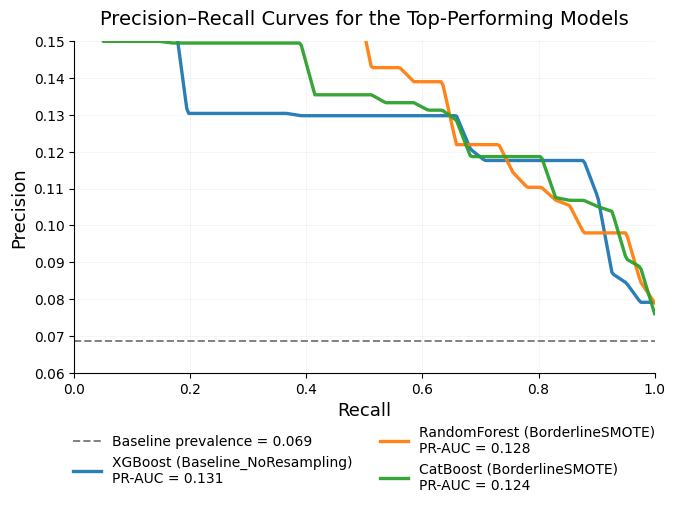

In [14]:
# ==========================================
# Precision–Recall Curves for Top-Performing Models
# Paper-ready version (Test - with feature engineering)
# ==========================================

from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt
import os

top_n = 3

top_models_df = imbalance_results_df.sort_values(
    ["PR-AUC", "ROC-AUC"],
    ascending=False
).head(top_n)

os.makedirs("reports_test/figures/pr_curves", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 6), facecolor="white")
ax.set_facecolor("white")

baseline_prevalence = y_test.mean()

ax.axhline(
    baseline_prevalence,
    linestyle="--",
    color="gray",
    linewidth=1.4,
    label=f"Baseline prevalence = {baseline_prevalence:.3f}"
)

recall_grid = np.linspace(0, 1, 300)

for _, row in top_models_df.iterrows():

    model_name  = row["Model"]
    method_name = row["Imbalance_Method"]
    pr_auc      = row["PR-AUC"]

    model_key = f"{model_name}__{method_name}"
    y_prob    = imbalance_models[model_key]["probs"]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    order     = np.argsort(recall)
    recall    = recall[order]
    precision = precision[order]

    uniq_recall    = np.unique(recall)
    uniq_precision = np.array([
        precision[recall == r].max() for r in uniq_recall
    ])

    precision_env    = np.maximum.accumulate(uniq_precision[::-1])[::-1]
    precision_smooth = np.interp(recall_grid, uniq_recall, precision_env)

    label = f"{model_name} ({method_name})\nPR-AUC = {pr_auc:.3f}"

    ax.plot(
        recall_grid,
        precision_smooth,
        linewidth=2.4,
        alpha=0.95,
        label=label
    )

ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision–Recall Curves for the Top-Performing Models", fontsize=14, pad=12)

ax.set_xlim(0, 1)
ax.set_ylim(0.06, 0.15)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.15, linewidth=0.6)

# legend ใต้กราฟ — ไม่ทับเส้น
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    fontsize=10,
    ncol=2
)

plt.tight_layout(rect=[0, 0.08, 1, 0.97])

plt.savefig(
    "reports_test/figures/pr_curves/top_models_pr_curve_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### 4. Feature Budget Optimization & SHAP XAI
ทำการหาจุดคุ้มทุนแบบพลวัต (Dynamic Cost-Effective Budget) และสร้างกราฟ SHAP ตามจำนวนตัวแปรที่เหมาะสมที่สุด

In [15]:
# ==========================================
# Feature Budget Optimization (XGBoost + Baseline)
# ==========================================

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.base import clone
import numpy as np
import pandas as pd

# ดึง final model
final_model_key = "XGBoost__Baseline_NoResampling"
xgb_model = imbalance_models[final_model_key]["model"]

# ดึง feature importance จาก XGBoost
# ใช้ gain-based importance เพื่อ rank features
import xgboost as xgb

booster = xgb_model.named_steps["model"] if hasattr(xgb_model, "named_steps") else xgb_model

feat_importance = pd.Series(
    booster.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 features by importance:")
print(feat_importance.head(20))

# -----------------------------
# Feature budget loop
# -----------------------------
group_cv_budget = GroupKFold(n_splits=3)
budget_results  = []

for k in range(1, len(feat_importance) + 1):

    top_k_features = feat_importance.index[:k].tolist()

    X_train_k = X_train[top_k_features]

    model_k = clone(booster)

    scores = cross_val_score(
        model_k,
        X_train_k,
        y_train,
        groups=groups_train,
        cv=group_cv_budget,
        scoring="average_precision",
        n_jobs=-1
    )

    budget_results.append({
        "Num_Features": k,
        "PR-AUC":       scores.mean(),
        "PR-AUC_std":   scores.std()
    })

    if k % 10 == 0 or k == 1:
        print(f"  k={k:3d}: PR-AUC = {scores.mean():.4f} ± {scores.std():.4f}")

budget_df_xgb = pd.DataFrame(budget_results)

# -----------------------------
# หา optimal k
# -----------------------------
# ใช้ 1-SE rule — เลือก k น้อยที่สุดที่ PR-AUC ไม่ต่างจาก max เกิน 1 SE
max_score_xgb = budget_df_xgb["PR-AUC"].max()
max_idx       = budget_df_xgb["PR-AUC"].idxmax()
se_at_max     = budget_df_xgb.loc[max_idx, "PR-AUC_std"] / np.sqrt(3)
threshold_1se = max_score_xgb - se_at_max

optimal_k_xgb = budget_df_xgb.loc[
    budget_df_xgb["PR-AUC"] >= threshold_1se,
    "Num_Features"
].min()

print(f"\nMax PR-AUC: {max_score_xgb:.4f} at k={budget_df_xgb.loc[max_idx, 'Num_Features']}")
print(f"1-SE threshold: {threshold_1se:.4f}")
print(f"Optimal k (1-SE rule): {optimal_k_xgb}")

# -----------------------------
# Save budget table
# -----------------------------
os.makedirs("reports_test/tables", exist_ok=True)
budget_df_xgb.to_excel(
    "reports_test/tables/feature_budget_xgb.xlsx",
    index=False
)

print("\n✅ Feature budget optimization complete")
print(budget_df_xgb.head(10))

Top 20 features by importance:
Uterine_Factors                   0.098630
First_Progressive_Motile          0.039906
Cycle_Day                         0.039648
Post_TPMSC                        0.039306
First_Count                       0.036827
Pre_Count                         0.035245
Total_Female_Pathology            0.035210
Post_Count                        0.034898
Delta_Motile                      0.034744
Age_Female                        0.033530
Gynecological_Surgical_History    0.032191
First_Volume                      0.030208
Ovulatory_Factors                 0.029607
First_Motile                      0.029061
Cycle_Number                      0.028837
Menstrual_Interval_Days           0.028283
Ratio_TPMSC                       0.027888
First_TotalMotile                 0.026840
Pre_Motile                        0.025825
Age_FSH_Interaction               0.025007
dtype: float32
  k=  1: PR-AUC = 0.0786 ± 0.0053
  k= 10: PR-AUC = 0.1152 ± 0.0284
  k= 20: PR-AUC = 0.1377 ±

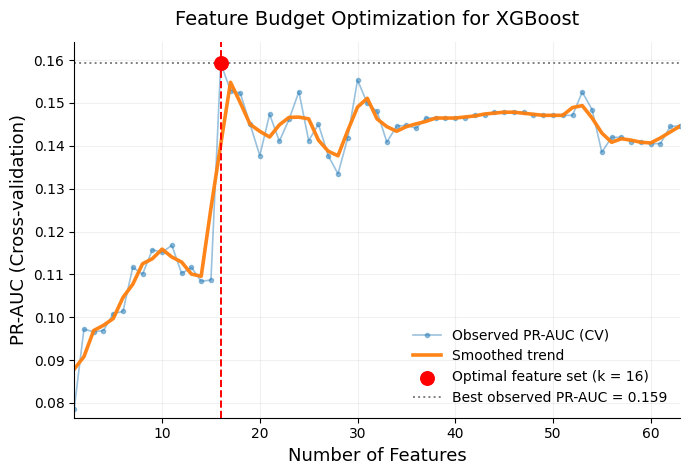

In [16]:
# ==========================================
# Feature Budget Optimization (XGBoost)
# Paper-ready figure (Test - with feature engineering)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("reports_test/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5), facecolor="white")
ax.set_facecolor("white")

x = budget_df_xgb["Num_Features"]
y = budget_df_xgb["PR-AUC"]

# smoothing (visual only)
y_smooth = y.rolling(window=3, center=True, min_periods=1).mean()

# Observed CV performance
ax.plot(
    x, y,
    marker="o",
    markersize=3,
    lw=1.2,
    alpha=0.45,
    label="Observed PR-AUC (CV)"
)

# Smoothed trend
ax.plot(
    x, y_smooth,
    lw=2.6,
    alpha=0.95,
    label="Smoothed trend"
)

# Optimal feature set
opt_y = budget_df_xgb.loc[
    budget_df_xgb["Num_Features"] == optimal_k_xgb,
    "PR-AUC"
].iloc[0]

ax.scatter(
    optimal_k_xgb, opt_y,
    s=95,
    color="red",
    zorder=6,
    label=f"Optimal feature set (k = {optimal_k_xgb})"
)

# Best observed PR-AUC reference line
ax.axhline(
    y=max_score_xgb,
    linestyle=":",
    linewidth=1.4,
    color="gray",
    label=f"Best observed PR-AUC = {max_score_xgb:.3f}"
)

# Optimal k vertical line
ax.axvline(
    x=optimal_k_xgb,
    linestyle="--",
    linewidth=1.4,
    color="red"
)

ax.set_xlabel("Number of Features", fontsize=13)
ax.set_ylabel("PR-AUC (Cross-validation)", fontsize=13)
ax.set_title("Feature Budget Optimization for XGBoost", fontsize=14, pad=12)

ax.set_xlim(1, x.max())
ax.set_ylim(y.min() - 0.002, y.max() + 0.005)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)

ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "reports_test/figures/feature_budget_xgb_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [18]:
# ==========================================
# Block 6B: Retrain XGBoost with optimal k features
# Final model: XGBoost + Baseline_NoResampling
# ==========================================

from xgboost import XGBClassifier
import joblib
import os

# -----------------------------
# เลือก top k features จาก budget optimization
# -----------------------------
selected_features_xgb = feat_importance.index[:optimal_k_xgb].tolist()

print(f"Selected {optimal_k_xgb} features:")
for i, f in enumerate(selected_features_xgb, start=1):
    print(f"  {i}. {f}")

X_train_final = X_train[selected_features_xgb].copy()
X_test_final  = X_test[selected_features_xgb].copy()

# -----------------------------
# Retrain XGBoost ด้วย best params จาก imbalance block
# -----------------------------
best_params = imbalance_models["XGBoost__Baseline_NoResampling"]["best_params"]

# ลบ prefix model__ ออกถ้ามี
clean_params = {
    k.replace("model__", ""): v
    for k, v in best_params.items()
}

final_xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    **clean_params
)

final_xgb_model.fit(X_train_final, y_train)

print(f"\n✅ Retrained XGBoost with {optimal_k_xgb} features")
print(f"Best params used: {clean_params}")

# save
os.makedirs("models_test/final_model", exist_ok=True)
joblib.dump(
    final_xgb_model,
    "models_test/final_model/XGBoost_Baseline_final_feature_budget_model.joblib"
)

Selected 16 features:
  1. Uterine_Factors
  2. First_Progressive_Motile
  3. Cycle_Day
  4. Post_TPMSC
  5. First_Count
  6. Pre_Count
  7. Total_Female_Pathology
  8. Post_Count
  9. Delta_Motile
  10. Age_Female
  11. Gynecological_Surgical_History
  12. First_Volume
  13. Ovulatory_Factors
  14. First_Motile
  15. Cycle_Number
  16. Menstrual_Interval_Days

✅ Retrained XGBoost with 16 features
Best params used: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}


['models_test/final_model/XGBoost_Baseline_final_feature_budget_model.joblib']

Final features used:
  1. Uterine_Factors
  2. First_Progressive_Motile
  3. Cycle_Day
  4. Post_TPMSC
  5. First_Count
  6. Pre_Count
  7. Total_Female_Pathology
  8. Post_Count
  9. Delta_Motile
  10. Age_Female
  11. Gynecological_Surgical_History
  12. First_Volume
  13. Ovulatory_Factors
  14. First_Motile
  15. Cycle_Number
  16. Menstrual_Interval_Days

Final model performance on test set:
PR-AUC:  0.1386
ROC-AUC: 0.6808
Brier:   0.2207

Top SHAP features:
                           Feature               Feature_Display  Importance
0                  Uterine_Factors                Uterine Factor    0.267127
1           Total_Female_Pathology        Total Female Pathology    0.067680
2          Menstrual_Interval_Days         Cycle Interval (days)    0.051831
3                       Post_TPMSC                Postwash TPMSC    0.051007
4                        Pre_Count           Prewash Sperm Count    0.046951
5                      First_Count           Initial Sperm Count    0.

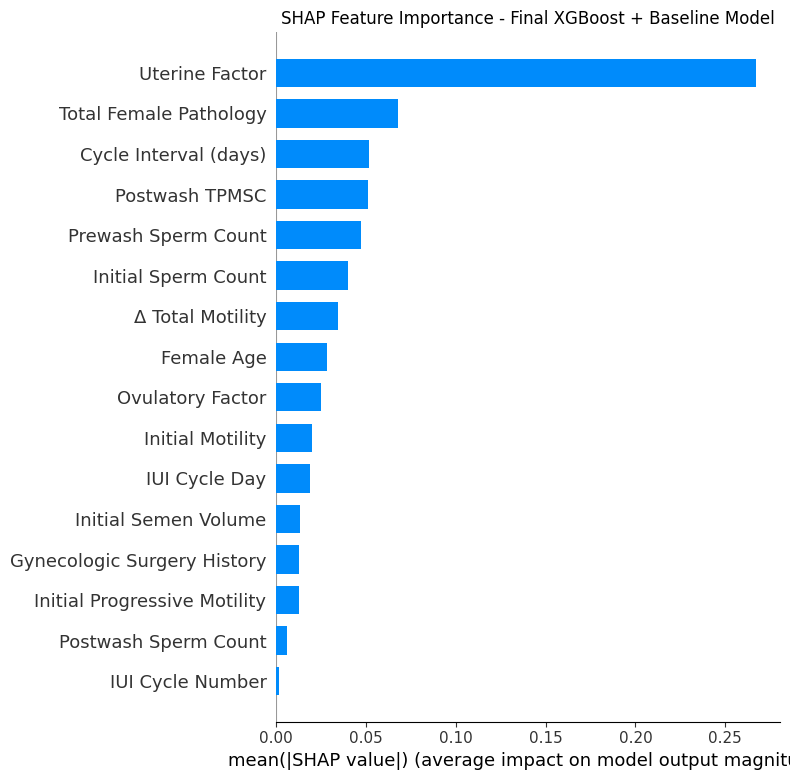

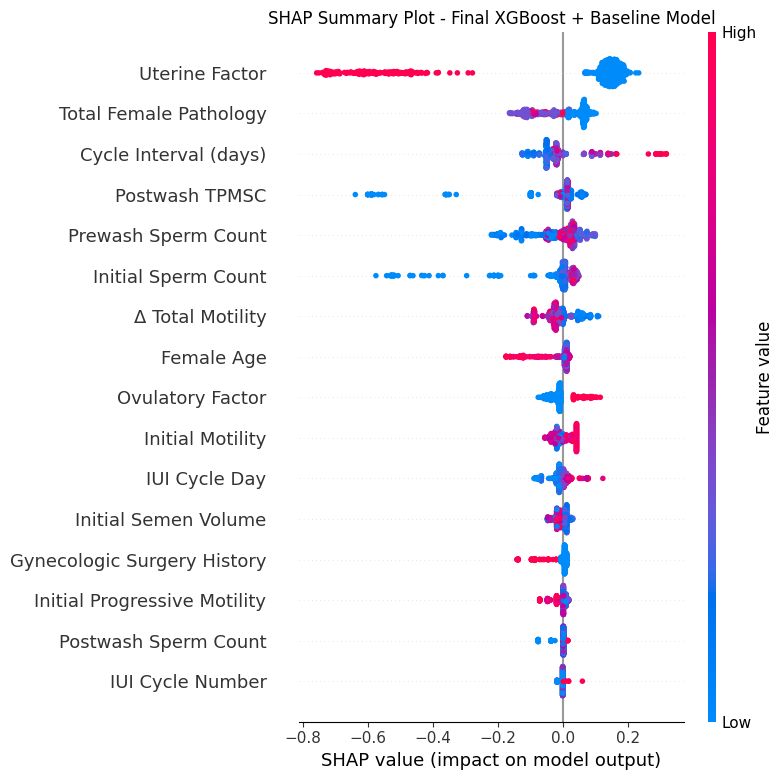


✅ Block 7 complete
Saved files:
- models_test/final_model/XGBoost_Baseline_final_feature_budget_model.joblib
- reports_test/tables/Final_Model_Performance_XGBoost_Baseline.xlsx
- reports_test/tables/Final_Selected_Features_XGBoost_Baseline.xlsx
- reports_test/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx
- reports_test/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx
- reports_test/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png
- reports_test/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png


In [21]:
# ==========================================
# Block 7: Final Model Evaluation + SHAP Analysis
# Final model = XGBoost + Baseline after feature budget
# ==========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss
)

os.makedirs("reports_test/figures/shap_final_xgb", exist_ok=True)
os.makedirs("reports_test/tables", exist_ok=True)
os.makedirs("models_test/final_model", exist_ok=True)

# -----------------------------
# Required objects
# -----------------------------
required_objects = [
    "selected_features_xgb",
    "final_xgb_model",
    "X_test",
    "y_test",
    "test_info"
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run the previous blocks first.")

# -----------------------------
# Final feature set
# -----------------------------
final_features = selected_features_xgb.copy()

missing_features = [f for f in final_features if f not in X_test.columns]
if missing_features:
    raise ValueError(f"These final features are missing from X_test: {missing_features}")

X_test_final = X_test[final_features].copy()

print("Final features used:")
for i, f in enumerate(final_features, start=1):
    print(f"  {i}. {f}")

# -----------------------------
# Final model probabilities on TEST
# -----------------------------
final_probs   = final_xgb_model.predict_proba(X_test_final)[:, 1]

final_pr_auc  = average_precision_score(y_test, final_probs)
final_roc_auc = roc_auc_score(y_test, final_probs)
final_brier   = brier_score_loss(y_test, final_probs)

print("\nFinal model performance on test set:")
print(f"PR-AUC:  {final_pr_auc:.4f}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Brier:   {final_brier:.4f}")

# -----------------------------
# Save final performance summary
# -----------------------------
final_model_summary = pd.DataFrame([{
    "Model": "XGBoost + Baseline (Final Feature-Budget Model)",
    "Num_Features": len(final_features),
    "PR-AUC":  final_pr_auc,
    "ROC-AUC": final_roc_auc,
    "Brier":   final_brier
}])

final_model_summary.to_excel(
    "reports_test/tables/Final_Model_Performance_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save final selected features
# -----------------------------
final_features_df = pd.DataFrame({
    "Rank":    range(1, len(final_features) + 1),
    "Feature": final_features
})

final_features_df.to_excel(
    "reports_test/tables/Final_Selected_Features_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Save final test-set predictions
# -----------------------------
final_test_pred_df = test_info.copy()
final_test_pred_df["y_true"] = y_test.values
final_test_pred_df["y_prob"] = final_probs

final_test_pred_df.to_excel(
    "reports_test/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx",
    index=False
)

# -----------------------------
# Feature name map for display
# -----------------------------
feature_name_map = {
    'Age_Female': 'Female Age',
    'Body_Mass_Index': 'BMI',
    'Total_infertile_duration': 'Infertility Duration',
    'Infertility_Type': 'Primary Infertility',
    'Pregnancy_History': 'Previous Pregnancy',
    'Number_Of_Alive_Children': 'Number of Children',
    'Number_Of_Miscarriages': 'Number of Miscarriages',
    'Menstrual': 'Regular Menstrual Cycle',
    'Menstrual_Interval_Days': 'Cycle Interval (days)',
    'Menstrual_Duration_Days': 'Menstrual Duration (days)',
    'Dysmenorrhea': 'Dysmenorrhea',
    'FSH_Baseline': 'Baseline FSH',
    'LH_Baseline': 'Baseline LH',
    'E2_Baseline': 'Baseline Estradiol',
    'PRL_Baseline': 'Baseline Prolactin',
    'Uterine_Factors': 'Uterine Factor',
    'Tubal_Factors': 'Tubal Factor',
    'Ovarian_Factors': 'Ovarian Factor',
    'Ovulatory_Factors': 'Ovulatory Factor',
    'Cervical_Factors': 'Cervical Factor',
    'Endometriosis_Factors': 'Endometriosis',
    'Multisystem_Factors': 'Multiple Infertility Factors',
    'Gynecological_Surgical_History': 'Gynecologic Surgery History',
    'Alcohol': 'Male Alcohol Consumption',
    'Smoke': 'Male Smoking',
    'First_Volume': 'Initial Semen Volume',
    'First_Count': 'Initial Sperm Count',
    'First_Motile': 'Initial Motility',
    'First_Progressive_Motile': 'Initial Progressive Motility',
    'First_Normal_Morpho': 'Initial Normal Morphology',
    'Pre_Volume': 'Prewash Volume',
    'Pre_Count': 'Prewash Sperm Count',
    'Pre_Motile': 'Prewash Motility',
    'Pre_Progressive_Motile': 'Prewash Progressive Motility',
    'Pre_TPMSC': 'Prewash TPMSC',
    'Post_Count': 'Postwash Sperm Count',
    'Post_Motile': 'Postwash Motility',
    'Post_Progressive_Motile': 'Postwash Progressive Motility',
    'Post_TPMSC': 'Postwash TPMSC',
    'Cycle_Type': 'Cycle Type',
    'Cycle_Day': 'IUI Cycle Day',
    'Cycle_Number': 'IUI Cycle Number',
    'Ovary_Stimulation_Round': 'Stimulation Round',
    'OI_Clomiphene': 'Clomiphene',
    'OI_Letrozole': 'Letrozole',
    'OI_Gonadotropins': 'Gonadotropins',
    'hCG_Used': 'hCG Trigger Used',
    'hCG_Type': 'hCG Type',
    'Mature_Follicle_Count': 'Mature Follicle Count',
    'Endometrium_Thickness': 'Endometrial Thickness',
    'Endo_Type_Triple': 'Triple Line Endometrium',
    'Endo_Type_Intermediate': 'Intermediate Endometrium',
    'Endo_Type_Mixed': 'Mixed Endometrium',
    # Feature engineering
    'Ratio_TPMSC': 'TPMSC Wash Ratio',
    'Delta_Progressive_Motile': 'Δ Progressive Motility',
    'Delta_Motile': 'Δ Total Motility',
    'Follicle_Endo_Product': 'Follicle × Endometrium',
    'Cumulative_Treatment': 'Cumulative Treatment',
    'Age_FSH_Interaction': 'Age × FSH',
    'BMI_InfertilityType_Interaction': 'BMI × Infertility Type',
    'Total_Female_Pathology': 'Total Female Pathology',
    'First_TotalMotile': 'Initial Total Motile Sperm'
}

display_names = [feature_name_map.get(f, f) for f in final_features]

X_test_final_named         = X_test_final.copy()
X_test_final_named.columns = display_names

# -----------------------------
# SHAP explainer
# -----------------------------
explainer   = shap.TreeExplainer(final_xgb_model)
shap_values = explainer.shap_values(X_test_final)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if not isinstance(shap_values, np.ndarray):
    raise ValueError("Unexpected SHAP output format.")

if shap_values.shape[1] != X_test_final.shape[1]:
    raise ValueError(
        f"SHAP shape mismatch: shap_values has {shap_values.shape[1]} features, "
        f"but X_test_final has {X_test_final.shape[1]} features."
    )

# -----------------------------
# SHAP feature importance table
# -----------------------------
feat_imp_final_xgb = pd.DataFrame({
    "Feature":         final_features,
    "Feature_Display": display_names,
    "Importance":      np.abs(shap_values).mean(axis=0)
}).sort_values("Importance", ascending=False).reset_index(drop=True)

feat_imp_final_xgb.to_excel(
    "reports_test/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx",
    index=False
)

print("\nTop SHAP features:")
print(feat_imp_final_xgb.to_string())

# -----------------------------
# SHAP bar plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    plot_type="bar",
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Feature Importance - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

# -----------------------------
# SHAP beeswarm plot
# -----------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_final_named,
    max_display=len(final_features),
    show=False
)
plt.title("SHAP Summary Plot - Final XGBoost + Baseline Model")
plt.tight_layout()
plt.savefig(
    "reports_test/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

print("\n✅ Block 7 complete")
print("Saved files:")
print("- models_test/final_model/XGBoost_Baseline_final_feature_budget_model.joblib")
print("- reports_test/tables/Final_Model_Performance_XGBoost_Baseline.xlsx")
print("- reports_test/tables/Final_Selected_Features_XGBoost_Baseline.xlsx")
print("- reports_test/tables/Final_Test_Predictions_XGBoost_Baseline.xlsx")
print("- reports_test/tables/SHAP_Feature_Importance_Final_XGBoost_Baseline.xlsx")
print("- reports_test/figures/shap_final_xgb/SHAP_Bar_Final_XGBoost_Baseline.png")
print("- reports_test/figures/shap_final_xgb/SHAP_Beeswarm_Final_XGBoost_Baseline.png")

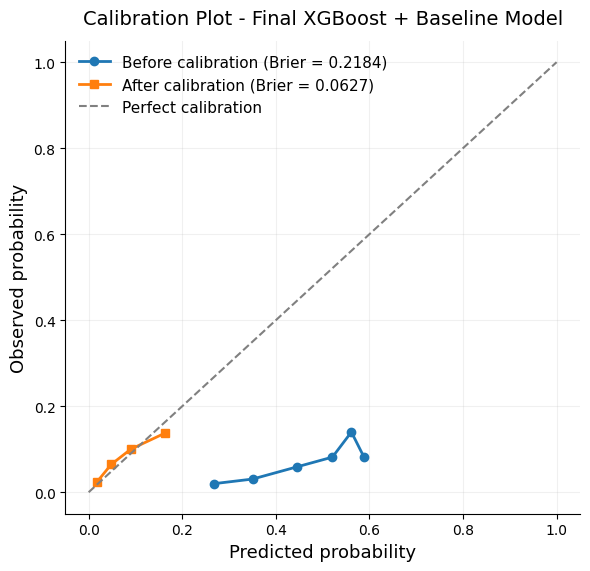

Brier before: 0.2184
Brier after:  0.0627
Improvement:  0.1557


In [24]:
# ==========================================
# Calibration Plot - Final XGBoost + Baseline Model
# Before and After Calibration (Proper - with calibration set)
# ==========================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs("reports_test/figures", exist_ok=True)

# -----------------------------
# แบ่ง calibration set จาก train set
# ใช้ stratify เพื่อรักษา event rate
# -----------------------------
X_tr, X_cal, y_tr, y_cal = train_test_split(
    X_train_final, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# -----------------------------
# Retrain XGBoost บน X_tr (train ที่ตัด cal ออก)
# ใช้ best params เดิม
# -----------------------------
from xgboost import XGBClassifier

xgb_for_cal = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    **clean_params
)
xgb_for_cal.fit(X_tr, y_tr)

# -----------------------------
# Fit isotonic regression บน calibration set
# -----------------------------
cal_probs = xgb_for_cal.predict_proba(X_cal)[:, 1]

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(cal_probs, y_cal)

# -----------------------------
# Evaluate บน TEST set
# -----------------------------
test_probs_raw        = xgb_for_cal.predict_proba(X_test_final)[:, 1]
test_probs_calibrated = iso_reg.predict(test_probs_raw)
test_probs_calibrated = np.clip(test_probs_calibrated, 0, 1)

brier_before = brier_score_loss(y_test, test_probs_raw)
brier_after  = brier_score_loss(y_test, test_probs_calibrated)

# -----------------------------
# Calibration curves
# -----------------------------
prob_true_before, prob_pred_before = calibration_curve(
    y_test, test_probs_raw,
    n_bins=6, strategy="quantile"
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test, test_probs_calibrated,
    n_bins=6, strategy="quantile"
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
ax.set_facecolor("white")

ax.plot(
    prob_pred_before, prob_true_before,
    marker="o", linewidth=2,
    label=f"Before calibration (Brier = {brier_before:.4f})"
)

ax.plot(
    prob_pred_after, prob_true_after,
    marker="s", linewidth=2,
    label=f"After calibration (Brier = {brier_after:.4f})"
)

ax.plot(
    [0, 1], [0, 1],
    linestyle="--", color="gray",
    label="Perfect calibration"
)

ax.set_xlabel("Predicted probability", fontsize=13)
ax.set_ylabel("Observed probability", fontsize=13)
ax.set_title("Calibration Plot - Final XGBoost + Baseline Model", fontsize=14, pad=12)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.grid(alpha=0.18)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    "reports_test/figures/Calibration_Plot_Final_XGBoost_Baseline.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Brier before: {brier_before:.4f}")
print(f"Brier after:  {brier_after:.4f}")
print(f"Improvement:  {brier_before - brier_after:.4f}")

Dependence features to plot: ['Uterine_Factors', 'Total_Female_Pathology', 'Menstrual_Interval_Days', 'Post_TPMSC', 'Pre_Count', 'First_Count', 'Delta_Motile', 'Age_Female', 'Ovulatory_Factors']


<Figure size 800x600 with 0 Axes>

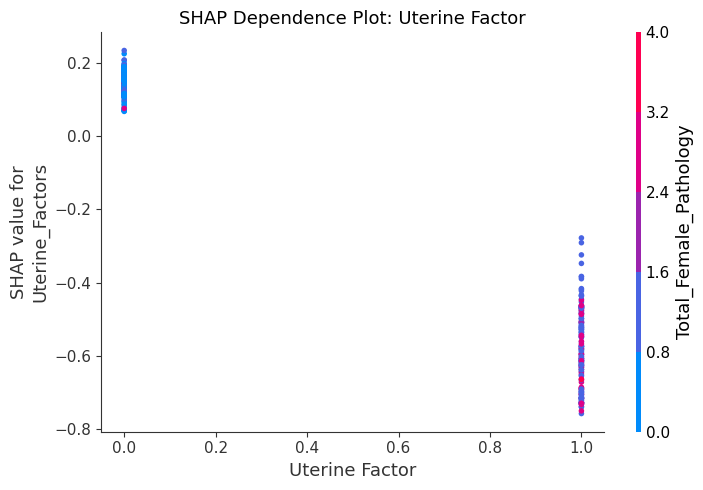

<Figure size 800x600 with 0 Axes>

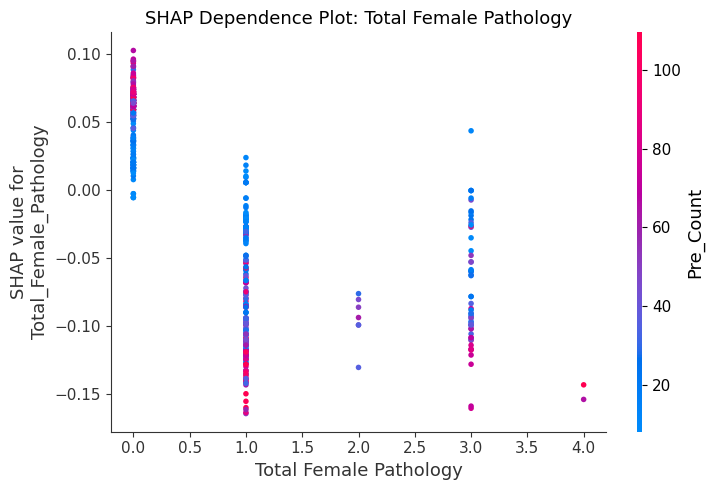

<Figure size 800x600 with 0 Axes>

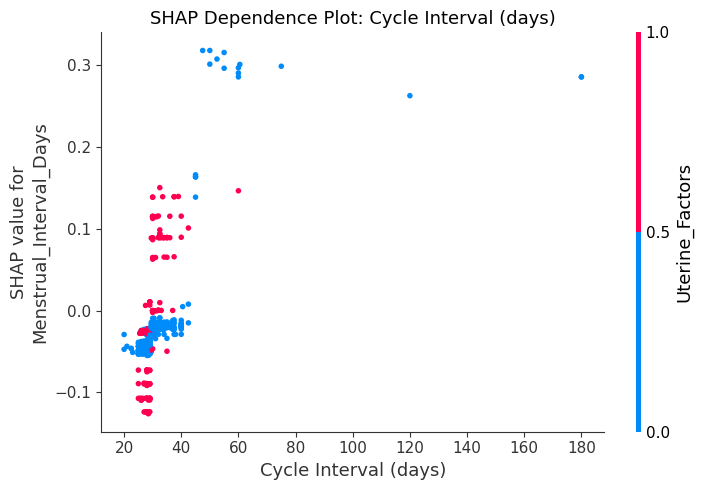

<Figure size 800x600 with 0 Axes>

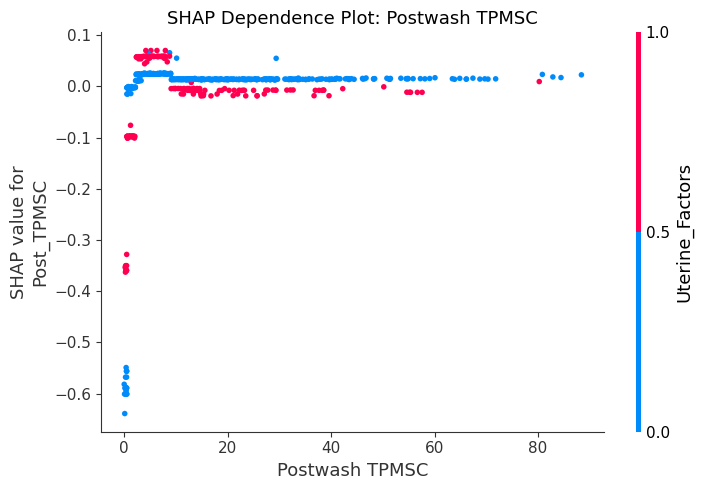

<Figure size 800x600 with 0 Axes>

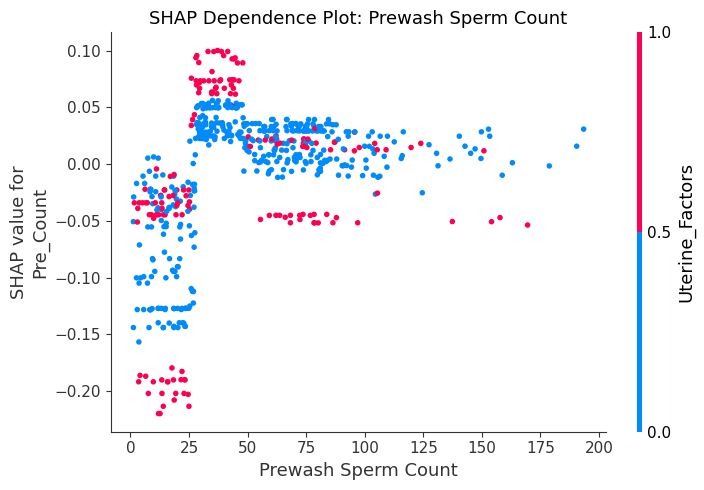

<Figure size 800x600 with 0 Axes>

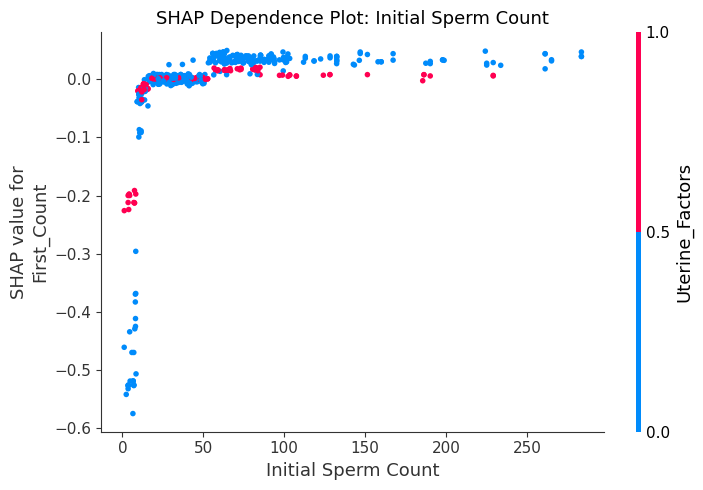

<Figure size 800x600 with 0 Axes>

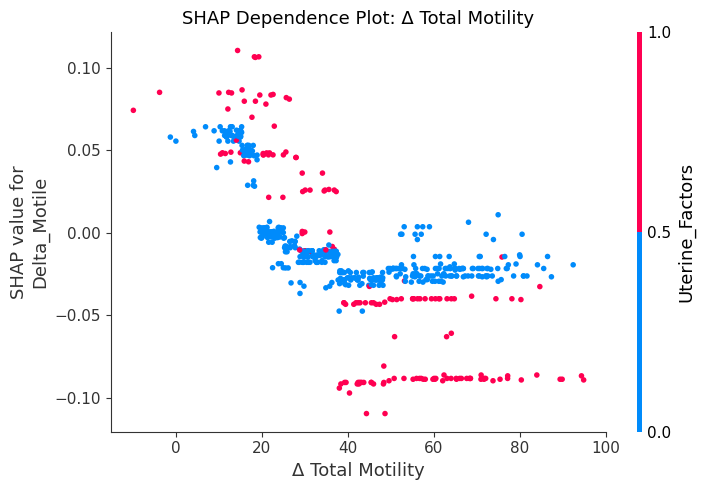

<Figure size 800x600 with 0 Axes>

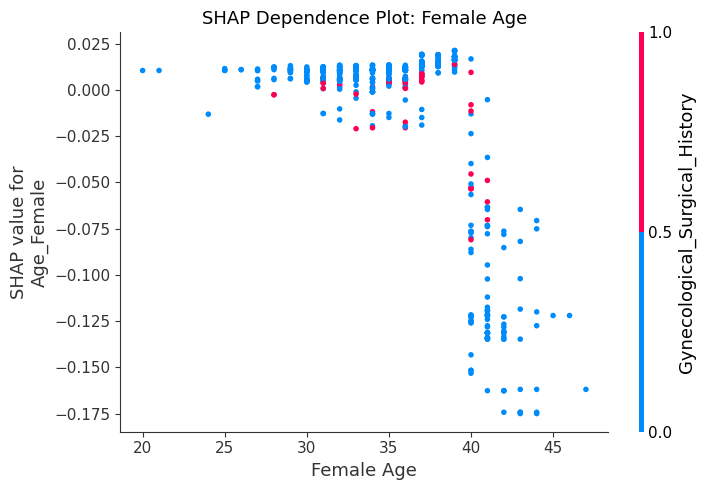

<Figure size 800x600 with 0 Axes>

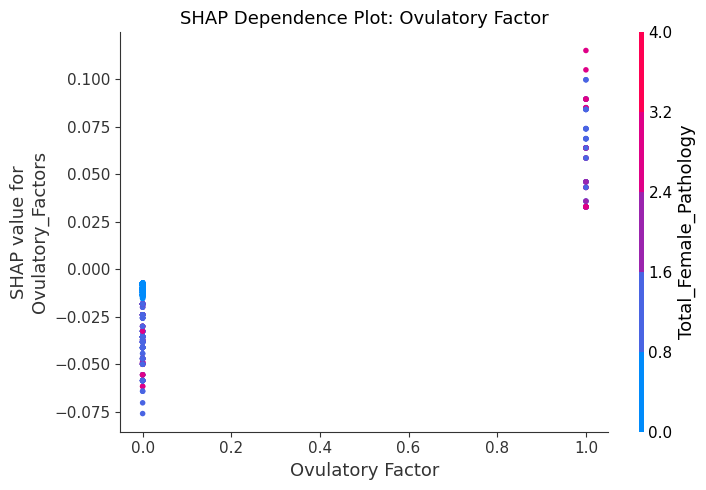

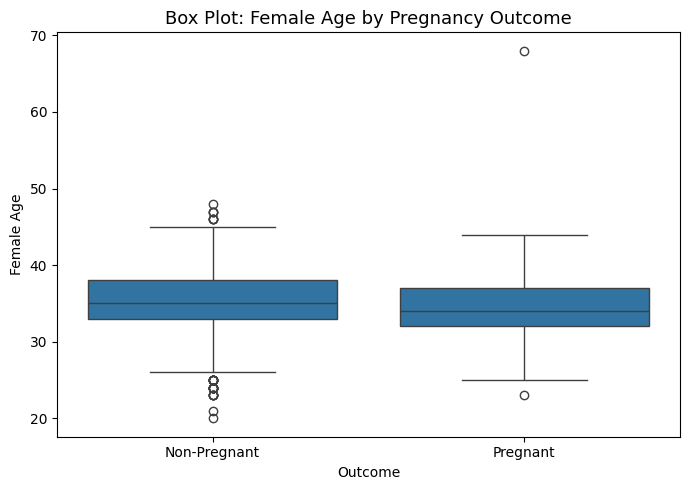

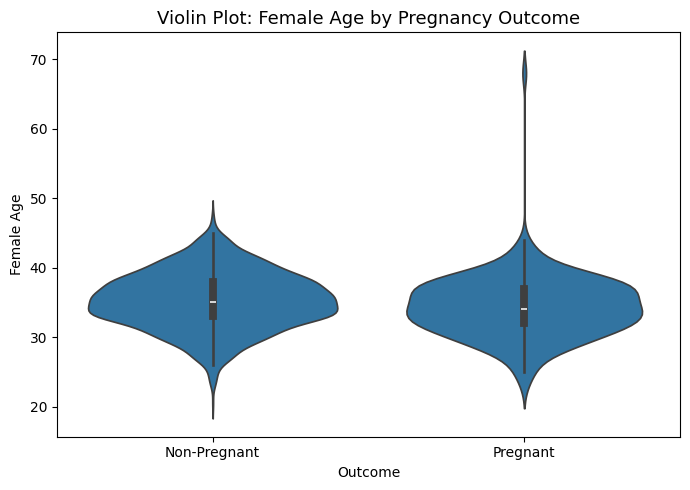

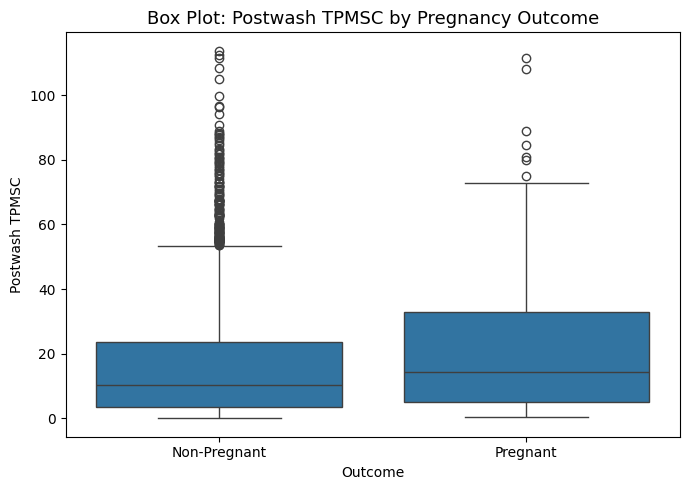

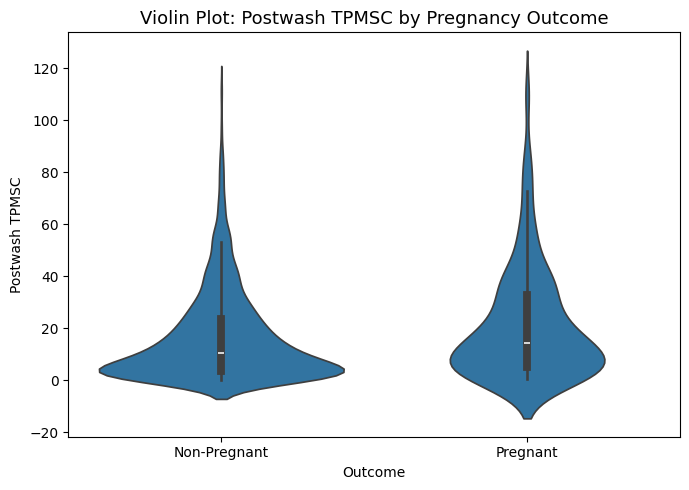

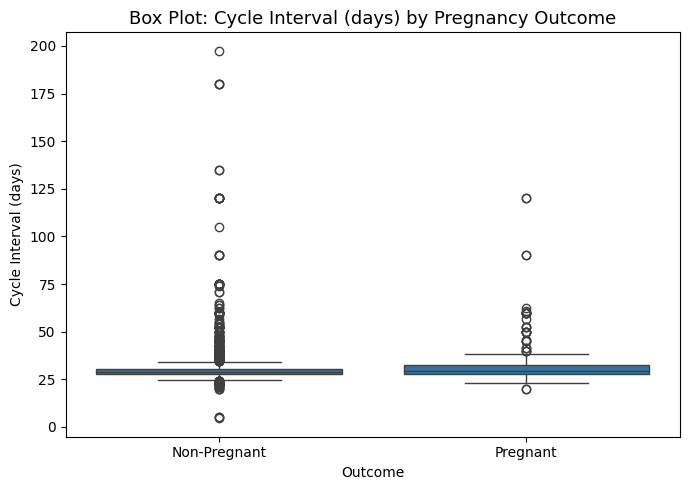

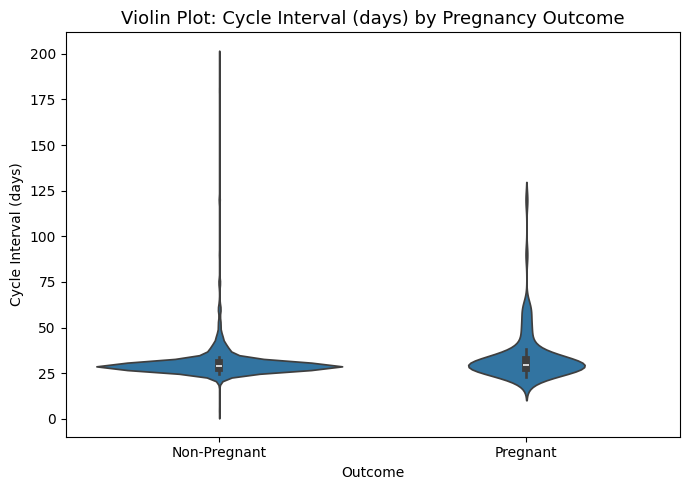

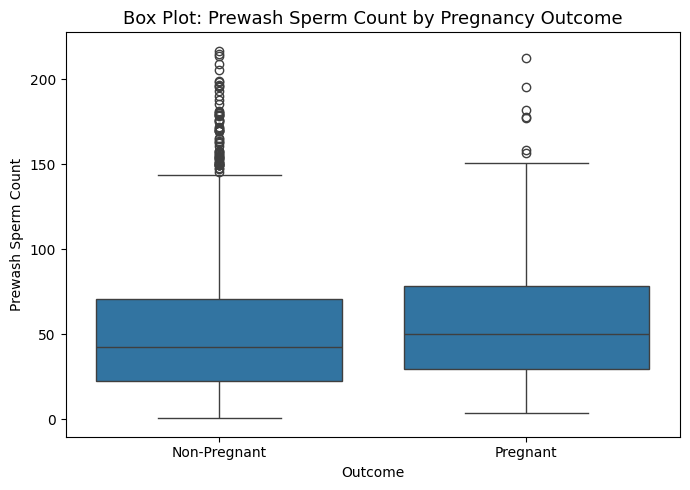

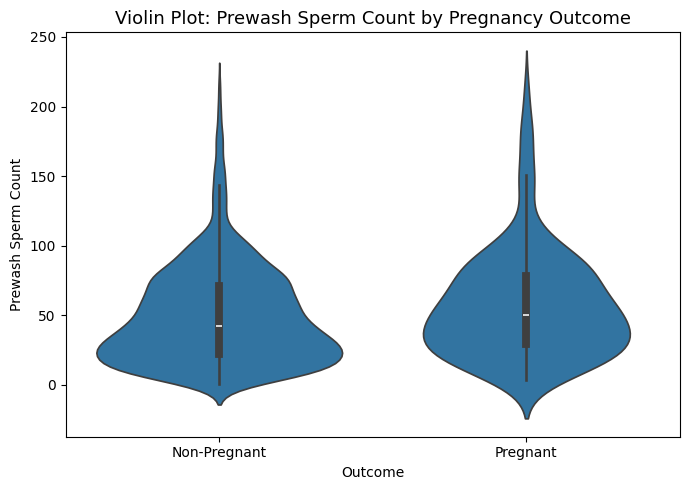

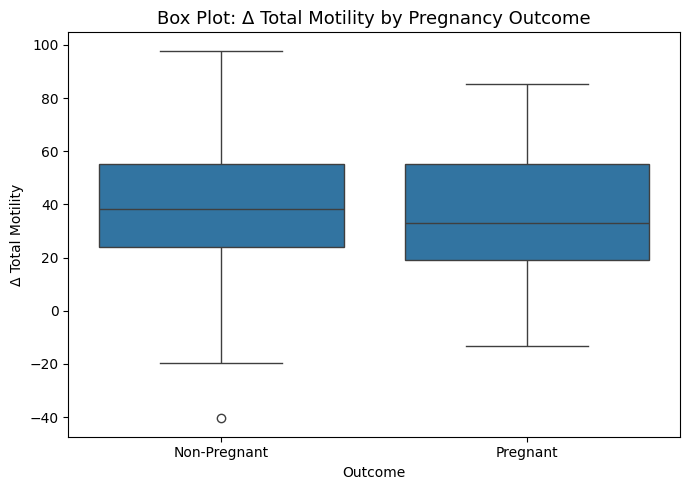

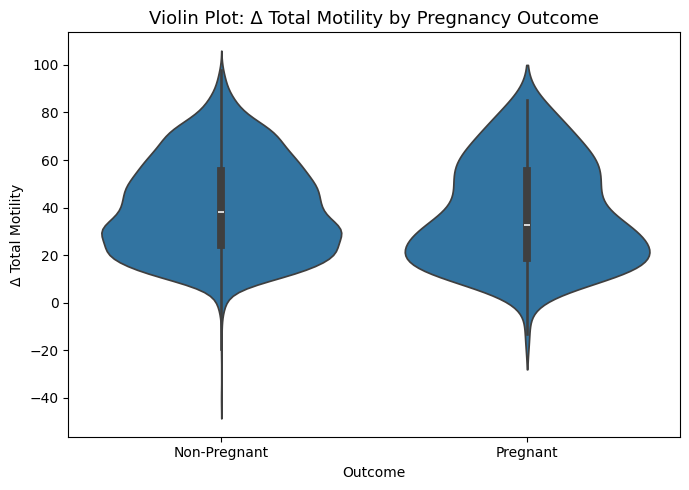

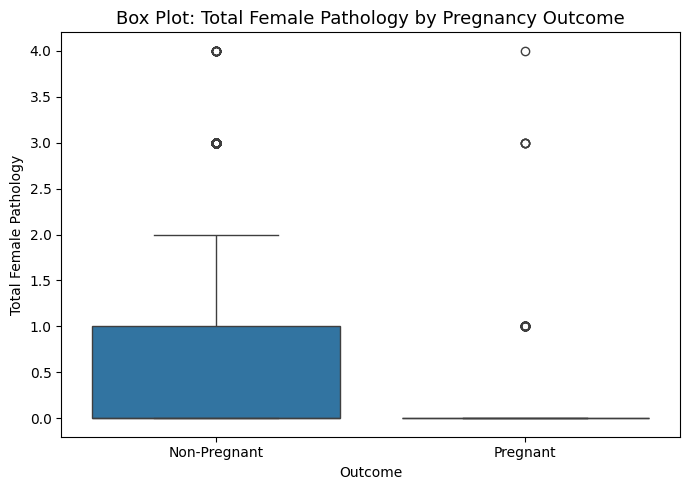

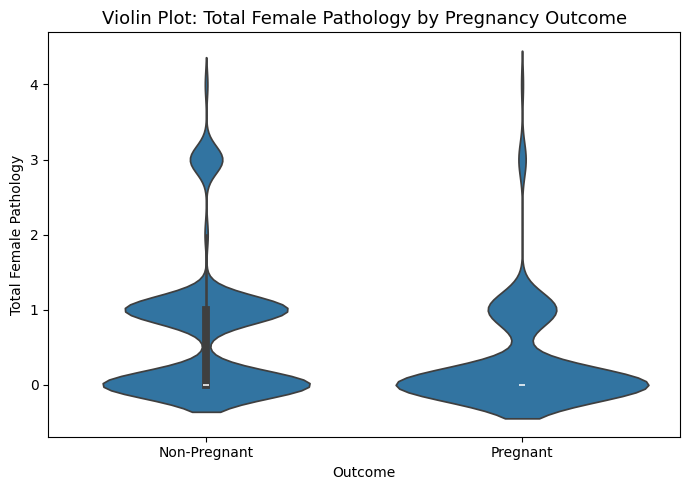

<Figure size 800x600 with 0 Axes>

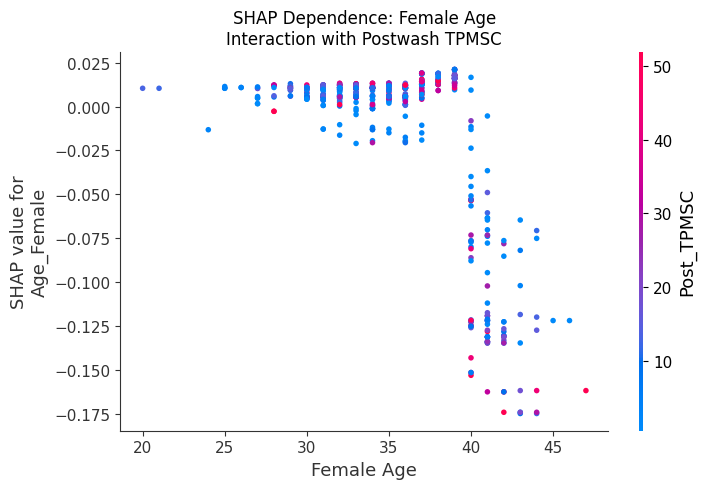


✅ SHAP Dependence + Clinical Plots complete


In [25]:
# =========================
# 4.3 SHAP Dependence Plots
# =========================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

os.makedirs('reports_test/figures/shap_dependence', exist_ok=True)
os.makedirs('reports_test/figures/clinical_plots', exist_ok=True)

# ใช้ object จาก final model block
for obj_name in ['feat_imp_final_xgb', 'shap_values', 'X_test_final', 'final_features']:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Please run final SHAP block first.")

# เลือก dependence features จาก 16 final features ที่มี SHAP importance สูง
candidate_dependence_features = [
    'Uterine_Factors',
    'Total_Female_Pathology',
    'Menstrual_Interval_Days',
    'Post_TPMSC',
    'Pre_Count',
    'First_Count',
    'Delta_Motile',
    'Age_Female',
    'Ovulatory_Factors',
]

top_feature_set = set(feat_imp_final_xgb['Feature'].head(15).tolist())
dependence_features = [
    f for f in candidate_dependence_features
    if f in X_test_final.columns and f in top_feature_set
]

print("Dependence features to plot:", dependence_features)

for feat in dependence_features:
    display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_final,
        interaction_index='auto',
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {display_name}', fontsize=13)
    plt.xlabel(display_name)
    plt.tight_layout()
    plt.savefig(
        f'reports_test/figures/shap_dependence/SHAP_Dependence_{feat}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
    plt.close()


# ==========================================
# 4.4 Clinical Box / Violin Plots by Outcome
# ==========================================

plot_df = df.copy()
plot_df = plot_df.loc[:, ~plot_df.columns.str.startswith('Unnamed')]

plot_df['Result'] = pd.to_numeric(plot_df['Result'], errors='coerce')
plot_df = plot_df.dropna(subset=['Result'])

plot_df['Pregnancy_Label'] = plot_df['Result'].map({
    0: 'Non-Pregnant',
    1: 'Pregnant'
})

# เลือก features ที่อยู่ใน final 16 features และเล่า biology ได้
clinical_plot_features = [
    'Age_Female',
    'Post_TPMSC',
    'Menstrual_Interval_Days',
    'Pre_Count',
    'Delta_Motile',
    'Total_Female_Pathology',
]

for feat in clinical_plot_features:
    if feat in plot_df.columns:
        display_name = feature_name_map.get(feat, feat) if 'feature_name_map' in globals() else feat

        tmp = plot_df[['Pregnancy_Label', feat]].copy()
        tmp[feat] = pd.to_numeric(tmp[feat], errors='coerce')
        tmp = tmp.dropna(subset=[feat, 'Pregnancy_Label'])

        if tmp.empty:
            print(f"⚠️ ไม่มีข้อมูลใช้ plot สำหรับ {feat}")
            continue

        # Boxplot
        plt.figure(figsize=(7, 5))
        sns.boxplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat
        )
        plt.title(f'Box Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_test/figures/clinical_plots/BoxPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

        # Violin plot
        plt.figure(figsize=(7, 5))
        sns.violinplot(
            data=tmp,
            x='Pregnancy_Label',
            y=feat,
            inner='box'
        )
        plt.title(f'Violin Plot: {display_name} by Pregnancy Outcome', fontsize=13)
        plt.xlabel('Outcome')
        plt.ylabel(display_name)
        plt.tight_layout()
        plt.savefig(
            f'reports_test/figures/clinical_plots/ViolinPlot_{feat}_by_Result.png',
            dpi=300,
            bbox_inches='tight'
        )
        plt.show()
        plt.close()

    else:
        print(f"⚠️ ไม่พบคอลัมน์ {feat} ใน plot_df เลยข้ามไป")


# ==========================================
# 4.5 SHAP Interaction Plot
# Female Age × Post_TPMSC
# ==========================================

if {'Age_Female', 'Post_TPMSC'}.issubset(X_test_final.columns):
    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        'Age_Female',
        shap_values,
        X_test_final,
        interaction_index='Post_TPMSC',
        show=False
    )

    plt.title('SHAP Dependence: Female Age\nInteraction with Postwash TPMSC')
    plt.xlabel('Female Age')
    plt.tight_layout()

    plt.savefig(
        'reports_test/figures/shap_dependence/SHAP_Dependence_FemaleAge_interaction_PostTPMSC.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()
    plt.close()

else:
    print("⚠️ ไม่พบ Age_Female หรือ Post_TPMSC ใน X_test_final")

print("\n✅ SHAP Dependence + Clinical Plots complete")

### 5. Clinical Analysis 1: Risk Stratification

Selected cutoffs: c1=0.4787, c2=0.5551
Selected quantiles: q1=0.40, q2=0.80


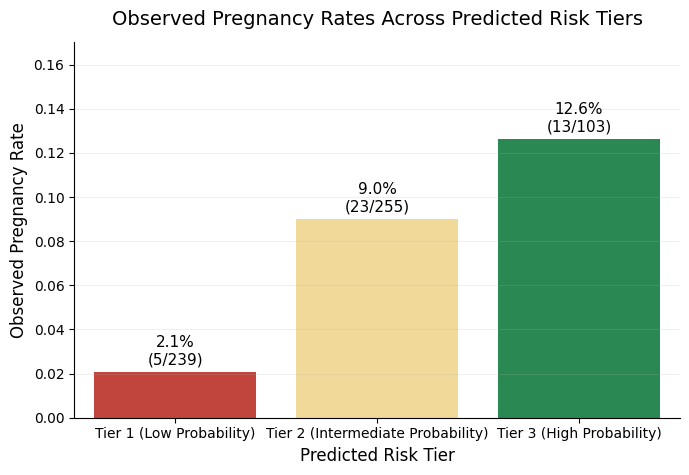


Risk Tier Summary:
                           Risk_Tier  Total_Cycles  Actual_Pregnancies  \
0           Tier 1 (Low Probability)           239                   5   
1  Tier 2 (Intermediate Probability)           255                  23   
2          Tier 3 (High Probability)           103                  13   

   Avg_Predicted_Prob  Min_Predicted_Prob  Max_Predicted_Prob  \
0            0.335540            0.197559            0.478700   
1            0.526179            0.478773            0.555085   
2            0.580219            0.555103            0.658237   

   Unique_Patients  Observed_Pregnancy_Rate  Predicted_minus_Observed  
0              160                 0.020921                  0.314620  
1              170                 0.090196                  0.435983  
2               80                 0.126214                  0.454005  


In [27]:
# =========================
# Block 8: Risk Tier Analysis (Monotonic / Pretty version)
# Search cut points that force Low < Mid < High
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_test/tables', exist_ok=True)
os.makedirs('reports_test/figures/clinical', exist_ok=True)

risk_df = test_info.copy()
risk_df['Predicted_Prob'] = final_probs
risk_df['Actual_Result'] = y_test.values
risk_df = risk_df.dropna(subset=['Predicted_Prob', 'Actual_Result']).copy()

tier_labels = [
    'Tier 1 (Low Probability)',
    'Tier 2 (Intermediate Probability)',
    'Tier 3 (High Probability)'
]

# --------------------------------
# search candidate cutoffs
# keep each tier at least 15% of data
# --------------------------------
q_grid = np.arange(0.20, 0.81, 0.05)

best_result = None
best_score  = -np.inf

for q1 in q_grid:
    for q2 in q_grid:
        if q2 <= q1:
            continue

        c1 = risk_df['Predicted_Prob'].quantile(q1)
        c2 = risk_df['Predicted_Prob'].quantile(q2)

        tmp = risk_df.copy()
        tmp['Risk_Tier'] = pd.cut(
            tmp['Predicted_Prob'],
            bins=[-np.inf, c1, c2, np.inf],
            labels=tier_labels,
            include_lowest=True
        )

        counts = tmp['Risk_Tier'].value_counts().reindex(tier_labels)
        if counts.isna().any():
            continue

        if (counts < int(len(tmp) * 0.15)).any():
            continue

        rates = (
            tmp.groupby('Risk_Tier', observed=False)['Actual_Result']
            .mean()
            .reindex(tier_labels)
        )

        if not (rates.iloc[0] < rates.iloc[1] < rates.iloc[2]):
            continue

        separation      = (rates.iloc[2] - rates.iloc[0]) + 0.5 * (rates.iloc[1] - rates.iloc[0])
        balance_penalty = counts.std() / counts.mean()
        score           = separation - 0.02 * balance_penalty

        if score > best_score:
            best_score  = score
            best_result = {
                'q1': q1, 'q2': q2,
                'c1': c1, 'c2': c2,
                'rates': rates,
                'counts': counts
            }

if best_result is None:
    raise ValueError(
        "No monotonic 3-tier split found with current constraints. "
        "Try relaxing the minimum tier size or widening q_grid."
    )

# --------------------------------
# apply best cutoffs
# --------------------------------
c1 = best_result['c1']
c2 = best_result['c2']

risk_df['Risk_Tier'] = pd.cut(
    risk_df['Predicted_Prob'],
    bins=[-np.inf, c1, c2, np.inf],
    labels=tier_labels,
    include_lowest=True
)

print(f"Selected cutoffs: c1={c1:.4f}, c2={c2:.4f}")
print(f"Selected quantiles: q1={best_result['q1']:.2f}, q2={best_result['q2']:.2f}")

# --------------------------------
# summary table
# --------------------------------
tier_summary = (
    risk_df
    .groupby('Risk_Tier', observed=False)
    .agg(
        Total_Cycles=('Actual_Result', 'count'),
        Actual_Pregnancies=('Actual_Result', 'sum'),
        Avg_Predicted_Prob=('Predicted_Prob', 'mean'),
        Min_Predicted_Prob=('Predicted_Prob', 'min'),
        Max_Predicted_Prob=('Predicted_Prob', 'max')
    )
    .reset_index()
)

if 'HN' in risk_df.columns:
    patient_counts = (
        risk_df
        .groupby('Risk_Tier', observed=False)['HN']
        .nunique()
        .reset_index(name='Unique_Patients')
    )
    tier_summary = tier_summary.merge(patient_counts, on='Risk_Tier', how='left')

tier_summary['Observed_Pregnancy_Rate'] = (
    tier_summary['Actual_Pregnancies'] / tier_summary['Total_Cycles']
)

tier_summary['Predicted_minus_Observed'] = (
    tier_summary['Avg_Predicted_Prob'] - tier_summary['Observed_Pregnancy_Rate']
)

tier_summary['Risk_Tier'] = pd.Categorical(
    tier_summary['Risk_Tier'],
    categories=tier_labels,
    ordered=True
)
tier_summary = tier_summary.sort_values('Risk_Tier').reset_index(drop=True)

tier_summary.to_excel(
    'reports_test/tables/Risk_Tier_Summary_FinalModel_Monotonic.xlsx',
    index=False
)

# --------------------------------
# plot
# --------------------------------
tier_colors = ['#d73027', '#fee08b', '#1a9850']

fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

sns.barplot(
    x='Risk_Tier',
    y='Observed_Pregnancy_Rate',
    data=tier_summary,
    palette=tier_colors,
    ax=ax
)

ax.set_title(
    'Observed Pregnancy Rates Across Predicted Risk Tiers',
    fontsize=14, pad=12
)
ax.set_ylabel('Observed Pregnancy Rate', fontsize=12)
ax.set_xlabel('Predicted Risk Tier', fontsize=12)

ymax = tier_summary['Observed_Pregnancy_Rate'].max()
ax.set_ylim(0, ymax * 1.35)

for i, row in tier_summary.iterrows():
    label = (
        f"{row['Observed_Pregnancy_Rate']:.1%}\n"
        f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})"
    )
    ax.text(
        i,
        row['Observed_Pregnancy_Rate'] + 0.002,
        label,
        ha='center',
        va='bottom',
        fontsize=11
    )

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    'reports_test/figures/clinical/Risk_Tier_Analysis_FinalModel_Monotonic.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\nRisk Tier Summary:")
print(tier_summary)

### 6. Clinical Analysis 2: Cumulative Cycle Impact

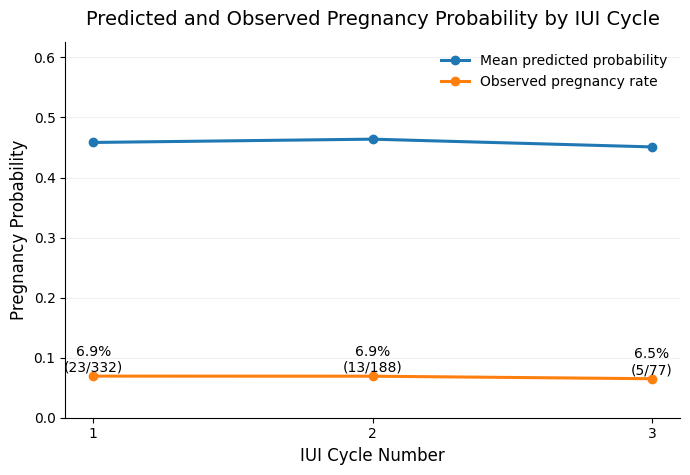


Cycle Summary:
   Cycle_Number  Total_Cycles  Actual_Pregnancies  Avg_Predicted_Prob  \
0             1           332                  23            0.458419   
1             2           188                  13            0.463893   
2             3            77                   5            0.450974   

   Observed_Pregnancy_Rate  
0                 0.069277  
1                 0.069149  
2                 0.064935  


In [28]:
# =========================
# Cycle Number Analysis
# Paper-ready version (Test - with feature engineering)
# =========================

import os
import matplotlib.pyplot as plt

os.makedirs('reports_test/tables', exist_ok=True)
os.makedirs('reports_test/figures/clinical', exist_ok=True)

if 'Cycle_Number' in risk_df.columns:

    cycle_summary = (
        risk_df
        .groupby('Cycle_Number')
        .agg(
            Total_Cycles=('Actual_Result', 'count'),
            Actual_Pregnancies=('Actual_Result', 'sum'),
            Avg_Predicted_Prob=('Predicted_Prob', 'mean')
        )
        .reset_index()
    )

    cycle_summary['Observed_Pregnancy_Rate'] = (
        cycle_summary['Actual_Pregnancies'] /
        cycle_summary['Total_Cycles']
    )

    cycle_summary = cycle_summary[
        cycle_summary['Cycle_Number'].isin([1, 2, 3])
    ].copy()
    cycle_summary = cycle_summary.sort_values('Cycle_Number')

    cycle_summary.to_excel(
        'reports_test/tables/Cycle_Number_Summary.xlsx',
        index=False
    )

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Avg_Predicted_Prob'],
        marker='o',
        linewidth=2.2,
        label='Mean predicted probability'
    )

    ax.plot(
        cycle_summary['Cycle_Number'],
        cycle_summary['Observed_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed pregnancy rate'
    )

    for _, row in cycle_summary.iterrows():
        ax.text(
            row['Cycle_Number'],
            row['Observed_Pregnancy_Rate'] + 0.002,
            f"{row['Observed_Pregnancy_Rate']:.1%}\n"
            f"({int(row['Actual_Pregnancies'])}/{int(row['Total_Cycles'])})",
            ha='center',
            va='bottom',
            fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('IUI Cycle Number', fontsize=12)
    ax.set_ylabel('Pregnancy Probability', fontsize=12)
    ax.set_title(
        'Predicted and Observed Pregnancy Probability by IUI Cycle',
        fontsize=14, pad=12
    )

    ymax = max(
        cycle_summary['Avg_Predicted_Prob'].max(),
        cycle_summary['Observed_Pregnancy_Rate'].max()
    )
    ax.set_ylim(0, ymax * 1.35)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test/figures/clinical/Cycle_Number_Analysis_Final.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

    print("\nCycle Summary:")
    print(cycle_summary)

else:
    print("ไม่มีตัวแปร Cycle_Number ให้วิเคราะห์")


CUMULATIVE PREGNANCY SUMMARY
   Patients  Avg_Predicted_Cumulative_Prob  Observed_Pregnancy_Rate
0       353                       0.604889                 0.116147


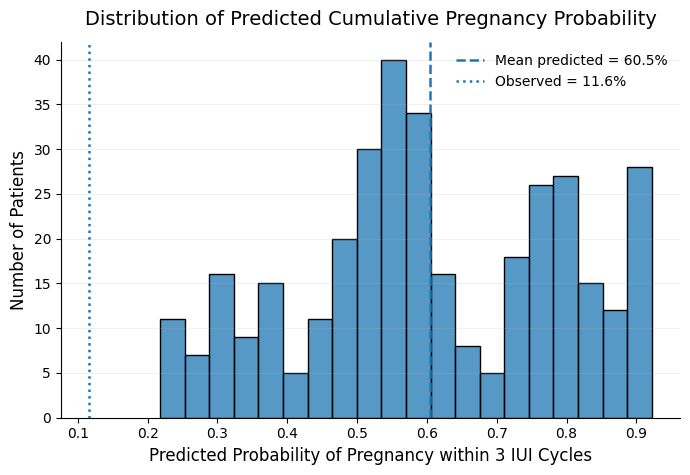

In [29]:
# ===============================
# 7. CUMULATIVE PREGNANCY ANALYSIS
# Paper-ready version (Test - with feature engineering)
# ===============================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('reports_test/figures/clinical', exist_ok=True)
os.makedirs('reports_test/tables', exist_ok=True)

if 'Cycle_Number' in risk_df.columns:

    cum_df = risk_df[risk_df['Cycle_Number'] <= 3].copy()
    cum_df = cum_df.sort_values(['HN', 'Cycle_Number'])

    cumulative_results = []

    for hn, g in cum_df.groupby('HN'):
        g = g.sort_values('Cycle_Number')

        p        = g['Predicted_Prob'].values
        cum_prob = 1 - np.prod(1 - p)

        cumulative_results.append({
            'HN':                          hn,
            'Num_Cycles':                  len(g),
            'Cumulative_Predicted_Prob':   cum_prob,
            'Actual_Pregnancy':            g['Actual_Result'].max()
        })

    cumulative_df = pd.DataFrame(cumulative_results)

    cumulative_df.to_excel(
        'reports_test/tables/Cumulative_Patient_Level.xlsx',
        index=False
    )

    cumulative_summary_df = pd.DataFrame([{
        "Patients":                        len(cumulative_df),
        "Avg_Predicted_Cumulative_Prob":   cumulative_df['Cumulative_Predicted_Prob'].mean(),
        "Observed_Pregnancy_Rate":         cumulative_df['Actual_Pregnancy'].mean()
    }])

    cumulative_summary_df.to_excel(
        'reports_test/tables/Cumulative_Summary.xlsx',
        index=False
    )

    print("\nCUMULATIVE PREGNANCY SUMMARY")
    print(cumulative_summary_df)

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    sns.histplot(
        cumulative_df['Cumulative_Predicted_Prob'],
        bins=20,
        ax=ax
    )

    mean_pred = cumulative_df['Cumulative_Predicted_Prob'].mean()
    obs_rate  = cumulative_df['Actual_Pregnancy'].mean()

    ax.axvline(
        mean_pred,
        linestyle='--',
        linewidth=1.8,
        label=f'Mean predicted = {mean_pred:.1%}'
    )

    ax.axvline(
        obs_rate,
        linestyle=':',
        linewidth=1.8,
        label=f'Observed = {obs_rate:.1%}'
    )

    ax.set_xlabel(
        'Predicted Probability of Pregnancy within 3 IUI Cycles',
        fontsize=12
    )
    ax.set_ylabel('Number of Patients', fontsize=12)
    ax.set_title(
        'Distribution of Predicted Cumulative Pregnancy Probability',
        fontsize=14, pad=12
    )

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test/figures/clinical/Cumulative_Pregnancy_Distribution.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("Cycle_Number not available")


Cumulative Success Summary:
   Cycle  Observed_Cumulative_Pregnancy_Rate  \
0      1                            0.065156   
1      2                            0.101983   
2      3                            0.116147   

   Model_Estimated_Cumulative_Probability  
0                                0.458419  
1                                0.577263  
2                                0.604889  


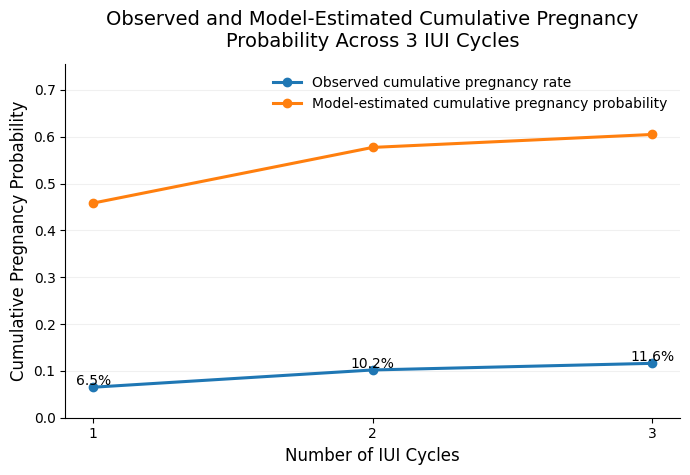

In [30]:
# =========================================
# 8. COHORT-LEVEL CUMULATIVE SUCCESS (1–3)
# Paper-ready version (Test - with feature engineering)
# =========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test/tables', exist_ok=True)
os.makedirs('reports_test/figures/clinical', exist_ok=True)

if 'Cycle_Number' in risk_df.columns and 'HN' in risk_df.columns:

    cum_plot_df = risk_df.copy()
    cum_plot_df = cum_plot_df[cum_plot_df['Cycle_Number'] <= 3].copy()
    cum_plot_df = cum_plot_df.sort_values(['HN', 'Cycle_Number'])

    patient_ids = cum_plot_df['HN'].dropna().unique()

    # -----------------------------
    # Observed cumulative pregnancy
    # -----------------------------
    actual_rows = []

    for k in [1, 2, 3]:
        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        preg_by_k = (
            sub.groupby('HN')['Actual_Result']
            .max()
            .reindex(patient_ids, fill_value=0)
        )

        actual_rows.append({
            'Cycle': k,
            'Observed_Cumulative_Pregnancy_Rate': preg_by_k.mean()
        })

    actual_cum_df = pd.DataFrame(actual_rows)

    # -----------------------------
    # Model-estimated cumulative probability
    # -----------------------------
    pred_rows = []

    for k in [1, 2, 3]:
        sub = cum_plot_df[cum_plot_df['Cycle_Number'] <= k].copy()

        patient_pred = []

        for hn in patient_ids:
            g = sub[sub['HN'] == hn].sort_values('Cycle_Number')

            if len(g) == 0:
                continue

            p        = g['Predicted_Prob'].values
            cum_prob = 1 - np.prod(1 - p)
            patient_pred.append(cum_prob)

        pred_rows.append({
            'Cycle': k,
            'Model_Estimated_Cumulative_Probability': np.mean(patient_pred)
        })

    pred_cum_df = pd.DataFrame(pred_rows)

    # -----------------------------
    # Merge summary
    # -----------------------------
    cumulative_summary_df = actual_cum_df.merge(pred_cum_df, on='Cycle')

    cumulative_summary_df.to_excel(
        'reports_test/tables/Cumulative_Success_By_Cycle.xlsx',
        index=False
    )

    print("\nCumulative Success Summary:")
    print(cumulative_summary_df)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'],
        marker='o',
        linewidth=2.2,
        label='Observed cumulative pregnancy rate'
    )

    ax.plot(
        cumulative_summary_df['Cycle'],
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'],
        marker='o',
        linewidth=2.2,
        label='Model-estimated cumulative pregnancy probability'
    )

    for _, row in cumulative_summary_df.iterrows():
        ax.text(
            row['Cycle'],
            row['Observed_Cumulative_Pregnancy_Rate'] + 0.005,
            f"{row['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            ha='center',
            fontsize=10
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Cumulative Pregnancy Probability', fontsize=12)
    ax.set_title(
        'Observed and Model-Estimated Cumulative Pregnancy\nProbability Across 3 IUI Cycles',
        fontsize=14, pad=12
    )

    ymax = max(
        cumulative_summary_df['Observed_Cumulative_Pregnancy_Rate'].max(),
        cumulative_summary_df['Model_Estimated_Cumulative_Probability'].max()
    )
    ax.set_ylim(0, ymax * 1.25)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test/figures/clinical/Cumulative_Success_By_Cycle.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("ต้องมีทั้ง HN และ Cycle_Number เพื่อคำนวณ cumulative success")


Cumulative Pregnancy by Risk Tier:
                           Risk_Tier  Cycle  Patients_in_Tier  \
0           Tier 1 (Low Probability)      1               160   
1           Tier 1 (Low Probability)      2               160   
2           Tier 1 (Low Probability)      3               160   
3  Tier 2 (Intermediate Probability)      1               170   
4  Tier 2 (Intermediate Probability)      2               170   
5  Tier 2 (Intermediate Probability)      3               170   
6          Tier 3 (High Probability)      1                80   
7          Tier 3 (High Probability)      2                80   
8          Tier 3 (High Probability)      3                80   

   Observed_Cumulative_Pregnancy_Rate  Pregnancies_by_Cycle_k  
0                            0.012500                       2  
1                            0.025000                       4  
2                            0.031250                       5  
3                            0.058824                    

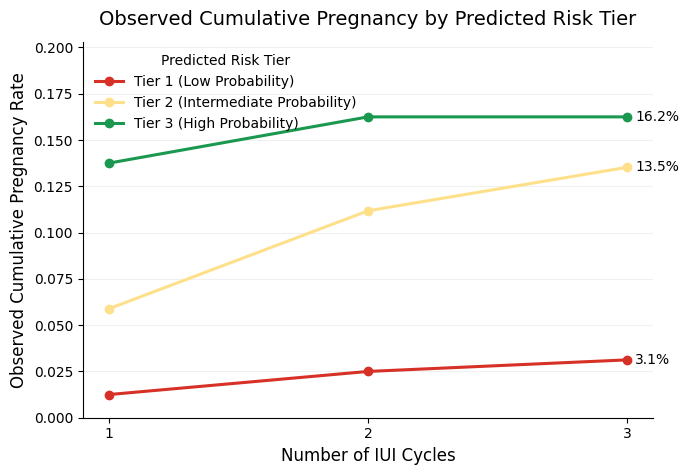

In [31]:
# ==========================================
# 9. CUMULATIVE PREGNANCY BY RISK TIER (1–3)
# Paper-ready version (Test - with feature engineering)
# ==========================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test/tables', exist_ok=True)
os.makedirs('reports_test/figures/clinical', exist_ok=True)

if 'HN' in risk_df.columns and 'Cycle_Number' in risk_df.columns:

    tier_cum_df = risk_df.copy()
    tier_cum_df = tier_cum_df[tier_cum_df['Cycle_Number'] <= 3].copy()
    tier_cum_df = tier_cum_df.sort_values(['HN', 'Cycle_Number'])

    # --------------------------------
    # Use monotonic risk-tier cutoffs
    # --------------------------------
    tier_order = [
        'Tier 1 (Low Probability)',
        'Tier 2 (Intermediate Probability)',
        'Tier 3 (High Probability)'
    ]

    if 'c1' not in globals() or 'c2' not in globals():
        raise ValueError("Risk-tier cutoffs c1 and c2 not found. Run the monotonic risk-tier block first.")

    tier_cum_df['Risk_Tier'] = pd.cut(
        tier_cum_df['Predicted_Prob'],
        bins=[-np.inf, c1, c2, np.inf],
        labels=tier_order,
        include_lowest=True
    )

    cumulative_rows = []

    for tier in tier_order:
        sub_tier = tier_cum_df[tier_cum_df['Risk_Tier'] == tier].copy()

        if sub_tier.empty:
            continue

        patient_ids = sub_tier['HN'].dropna().unique()

        for k in [1, 2, 3]:
            sub_k = sub_tier[sub_tier['Cycle_Number'] <= k].copy()

            preg_by_k = (
                sub_k.groupby('HN')['Actual_Result']
                .max()
                .reindex(patient_ids, fill_value=0)
            )

            cumulative_rows.append({
                'Risk_Tier':                          tier,
                'Cycle':                              k,
                'Patients_in_Tier':                   len(patient_ids),
                'Observed_Cumulative_Pregnancy_Rate': preg_by_k.mean(),
                'Pregnancies_by_Cycle_k':             int(preg_by_k.sum())
            })

    tier_cumulative_summary = pd.DataFrame(cumulative_rows)

    tier_cumulative_summary.to_excel(
        'reports_test/tables/Cumulative_Pregnancy_By_Risk_Tier.xlsx',
        index=False
    )

    print("\nCumulative Pregnancy by Risk Tier:")
    print(tier_cumulative_summary)

    # -------------------------
    # Plot
    # -------------------------
    tier_color_map = {
        'Tier 1 (Low Probability)':           '#d73027',
        'Tier 2 (Intermediate Probability)':  '#fee08b',
        'Tier 3 (High Probability)':          '#1a9850'
    }

    fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
    ax.set_facecolor('white')

    for tier in tier_order:
        sub = tier_cumulative_summary[
            tier_cumulative_summary['Risk_Tier'] == tier
        ].copy()

        if sub.empty:
            continue

        ax.plot(
            sub['Cycle'],
            sub['Observed_Cumulative_Pregnancy_Rate'],
            marker='o',
            linewidth=2.2,
            label=tier,
            color=tier_color_map[tier]
        )

        last_row = sub.sort_values('Cycle').iloc[-1]
        ax.text(
            last_row['Cycle'] + 0.03,
            last_row['Observed_Cumulative_Pregnancy_Rate'],
            f"{last_row['Observed_Cumulative_Pregnancy_Rate']:.1%}",
            fontsize=10,
            va='center'
        )

    ax.set_xticks([1, 2, 3])
    ax.set_xlabel('Number of IUI Cycles', fontsize=12)
    ax.set_ylabel('Observed Cumulative Pregnancy Rate', fontsize=12)
    ax.set_title(
        'Observed Cumulative Pregnancy by Predicted Risk Tier',
        fontsize=14, pad=12
    )

    ymax = tier_cumulative_summary['Observed_Cumulative_Pregnancy_Rate'].max()
    ax.set_ylim(0, ymax * 1.25)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.grid(axis='y', alpha=0.18)
    ax.legend(title='Predicted Risk Tier', frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    plt.savefig(
        'reports_test/figures/clinical/Cumulative_Pregnancy_By_Risk_Tier.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    plt.show()

else:
    print("ต้องมี HN และ Cycle_Number ใน risk_df")

### 7. Decision Curve Analysis (DCA)

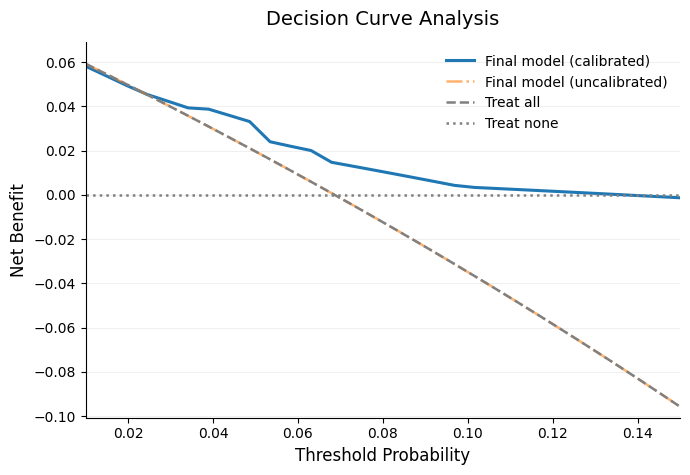


✅ DCA complete for final model
Saved:
- reports_test/tables/DCA_Analysis_Final_Model.xlsx
- reports_test/figures/dca/DCA_Final_Model.png


In [33]:
# =========================
# 10. Decision Curve Analysis
# Final model version (Test - with feature engineering)
# Using calibrated probabilities
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs('reports_test/tables', exist_ok=True)
os.makedirs('reports_test/figures/dca', exist_ok=True)

# clinically relevant threshold range
thresholds = np.linspace(0.01, 0.15, 30)

# require final model outputs
required_objects = ['y_test', 'final_probs', 'test_probs_calibrated']
for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"{obj_name} not found. Run the final model block first.")

# -----------------------------
# Net benefit calculations
# -----------------------------
nb_model_raw = [
    calculate_net_benefit(y_test, final_probs, t)
    for t in thresholds
]

nb_model_cal = [
    calculate_net_benefit(y_test, test_probs_calibrated, t)
    for t in thresholds
]

nb_all = [
    calculate_net_benefit(y_test, np.ones(len(y_test)), t)
    for t in thresholds
]

nb_none = [0.0] * len(thresholds)

# save table
dca_df = pd.DataFrame({
    'Threshold':                    thresholds,
    'Net_Benefit_Raw':              nb_model_raw,
    'Net_Benefit_Calibrated':       nb_model_cal,
    'Treat_All':                    nb_all,
    'Treat_None':                   nb_none
})

dca_df.to_excel(
    'reports_test/tables/DCA_Analysis_Final_Model.xlsx',
    index=False
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5), facecolor='white')
ax.set_facecolor('white')

ax.plot(
    thresholds, nb_model_cal,
    linewidth=2.2,
    label='Final model (calibrated)'
)

ax.plot(
    thresholds, nb_model_raw,
    linewidth=1.8,
    linestyle='-.',
    alpha=0.6,
    label='Final model (uncalibrated)'
)

ax.plot(
    thresholds, nb_all,
    color='gray',
    linestyle='--',
    linewidth=1.8,
    label='Treat all'
)

ax.plot(
    thresholds, nb_none,
    color='gray',
    linestyle=':',
    linewidth=1.8,
    label='Treat none'
)

ax.set_xlabel('Threshold Probability', fontsize=12)
ax.set_ylabel('Net Benefit', fontsize=12)
ax.set_title('Decision Curve Analysis', fontsize=14, pad=12)

ax.set_xlim(0.01, 0.15)

ymin = min(
    np.nanmin(nb_model_raw),
    np.nanmin(nb_model_cal),
    np.nanmin(nb_all),
    0
)
ymax = max(
    np.nanmax(nb_model_raw),
    np.nanmax(nb_model_cal),
    np.nanmax(nb_all),
    0
)
ax.set_ylim(ymin - 0.005, ymax + 0.01)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.grid(axis='y', alpha=0.18)
ax.legend(frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    'reports_test/figures/dca/DCA_Final_Model.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\n✅ DCA complete for final model")
print("Saved:")
print("- reports_test/tables/DCA_Analysis_Final_Model.xlsx")
print("- reports_test/figures/dca/DCA_Final_Model.png")